# Analiza frekwencji
Wersja 2 — z filtrem klas piątych (do końca kwietnia), wykresami Plotly i porównaniem roczników.

In [2]:
import pandas as pd
import hashlib
import re
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Wczytanie danych

In [3]:
df_2020_2021 = pd.read_excel("dane/frekw2020_2021.xlsx", sheet_name="Frekwencja - dane źródłowe")
df_2021_2022 = pd.read_excel("dane/frekw2021_2022.xlsx", sheet_name="Frekwencja - dane źródłowe")
df_2022_2023 = pd.read_excel("dane/frekw2022_2023.xlsx", sheet_name="Frekwencja - dane źródłowe")
df_2023_2024 = pd.read_excel("dane/frekw2023_2024.xlsx", sheet_name="Frekwencja - dane źródłowe")
df_2024_2025 = pd.read_excel("dane/frekw2024_2025.xlsx", sheet_name="Frekwencja - dane źródłowe")
df_2025_2026 = pd.read_excel("dane/frekw2025_2026.xlsx", sheet_name="Frekwencja - dane źródłowe")

## Filtrowanie — od września danego roku

In [4]:
df_2020_2021 = df_2020_2021[df_2020_2021['Data lekcji'] > '2020-09-01'].copy()
df_2021_2022 = df_2021_2022[df_2021_2022['Data lekcji'] > '2021-09-01'].copy()
df_2022_2023 = df_2022_2023[df_2022_2023['Data lekcji'] > '2022-09-01'].copy()
df_2023_2024 = df_2023_2024[df_2023_2024['Data lekcji'] > '2023-09-01'].copy()
df_2024_2025 = df_2024_2025[df_2024_2025['Data lekcji'] > '2024-09-01'].copy()
df_2025_2026 = df_2025_2026[df_2025_2026['Data lekcji'] > '2025-09-01'].copy()

In [5]:
df_2020_2021.columns

Index(['Szkoła', 'Dziennik', 'Uczeń', 'Data lekcji', 'Numer pory lekcji',
       'Przedmiot', 'Grupa', 'Nauczyciel', 'Symbol wpisu frekwencji',
       'Nazwa wpisu frekwencji', 'Kategoria typów wpisów frekwencji'],
      dtype='str')

## Anonimizacja uczniów

In [6]:
SALT = "moja_szkola_2026"  # NIE zmieniaj między latami!

def normalizuj(tekst):
    return " ".join(str(tekst).strip().split()).upper()

def parsuj_ucznia(uczen_str):
    return uczen_str.split(",")[0].strip()

def uczen_hash(nazwisko_imie, szkola):
    klucz = f"{SALT}|{normalizuj(szkola)}|{normalizuj(nazwisko_imie)}"
    return hashlib.sha256(klucz.encode()).hexdigest()[:10].upper()

def nauczyciel_hash(nauczyciel_str):
    klucz = f"{SALT}|NAUCZYCIEL|{normalizuj(nauczyciel_str)}"
    return "N_" + hashlib.sha256(klucz.encode()).hexdigest()[:8].upper()

def anonimizuj(df, rok_szkolny):
    df = df.copy()
    df["_nazwisko_imie"] = df["Uczeń"].apply(parsuj_ucznia)
    df["uczen_id"]       = df.apply(lambda r: uczen_hash(r["_nazwisko_imie"], r["Szkoła"]), axis=1)
    df["nauczyciel_id"]  = df["Nauczyciel"].apply(nauczyciel_hash)
    df["rok_szkolny"]    = rok_szkolny

    mapping = (
        df[["_nazwisko_imie", "Szkoła", "uczen_id"]]
        .drop_duplicates()
        .rename(columns={"_nazwisko_imie": "nazwisko_imie"})
        .sort_values("uczen_id")
        .reset_index(drop=True)
    )
    df = df.drop(columns=["Uczeń", "Nauczyciel", "_nazwisko_imie"]).copy()
    df = df[[
        "uczen_id", "rok_szkolny", "Szkoła", "Dziennik",
        "Data lekcji", "Numer pory lekcji", "Przedmiot", "Grupa", "nauczyciel_id",
        "Symbol wpisu frekwencji", "Nazwa wpisu frekwencji",
        "Kategoria typów wpisów frekwencji",
    ]]
    return df, mapping

In [7]:
df_2020_2021, mapping = anonimizuj(df_2020_2021, rok_szkolny="2020/2021")
df_2021_2022, mapping = anonimizuj(df_2021_2022, rok_szkolny="2021/2022")
df_2022_2023, mapping = anonimizuj(df_2022_2023, rok_szkolny="2022/2023")
df_2023_2024, mapping = anonimizuj(df_2023_2024, rok_szkolny="2023/2024")
df_2024_2025, mapping = anonimizuj(df_2024_2025, rok_szkolny="2024/2025")
df_2025_2026, mapping = anonimizuj(df_2025_2026, rok_szkolny="2025/2026")

In [8]:
mapping

,nazwisko_imie,Szkoła,uczen_id
0,Kępczyński Michał,BS1_P,0033BC69A3
1,Rokicki Dominik,BS1_P,0244E1B6BF
2,Szewczyk Sandra Luiza,Tech_M_P,02A96D4364
3,Grąbczewski Jakub,Tech_M_P,0373CBE4B4
4,Frelke Przemysław,Tech_M_P,03AEB33741
...,...,...,...
439,Różańska Aleksandra,Tech_M_P,FD77904472
440,Czarnomski Kacper,Tech_M_P,FDAEE28602
441,Kośmider-Jones Elżbieta Marta,Tech_M_P,FF695639B2
442,Murawska Oliwia,Tech_M_P,FF82200A74


## Zamiana wpisów frekwencji na kolumny dummy

In [9]:
df_list = [df_2020_2021, df_2021_2022, df_2022_2023, df_2023_2024, df_2024_2025, df_2025_2026]
df_list_ = []

for df in df_list:
    df = df.drop(columns=["Symbol wpisu frekwencji", "Kategoria typów wpisów frekwencji"]).copy()
    dummies = pd.get_dummies(df["Nazwa wpisu frekwencji"], prefix="wpis", dtype=int)
    df = pd.concat([df.drop(columns=["Nazwa wpisu frekwencji"]), dummies], axis=1)
    df_list_.append(df)

df_2020_2021, df_2021_2022, df_2022_2023, df_2023_2024, df_2024_2025, df_2025_2026 = df_list_

In [10]:
df_2020_2021.sample(5)

,uczen_id,rok_szkolny,Szkoła,Dziennik,Data lekcji,Numer pory lekcji,Przedmiot,Grupa,nauczyciel_id,wpis_nauka zdalna,wpis_nieob. uspr. p.s.,wpis_nieob. uspraw.,wpis_nieobecność,wpis_obecność,wpis_spóźn. uspr.,wpis_spóźnienie,wpis_zwolniony
184669,094EE79A92,2020/2021,Tech_M_P,1TM5,2021-06-01,7,Język angielski (j. angielski),cały oddział,N_3B3FA769,0,0,1,0,0,0,0,0
231232,B33F428A33,2020/2021,Tech_M_P,1TŻ5,2020-09-18,2,Edukacja dla bezpieczeństwa (e_dla_bezp),cały oddział,N_2A0644CE,0,0,0,0,1,0,0,0
258134,54C1680A6B,2020/2021,Tech_M_P,2RŻ5,2020-09-16,7,Język angielski (j. angielski),t.rolnikG (tr),N_0E9F92AA,0,0,0,0,1,0,0,0
326552,421106620E,2020/2021,BS1_P,2MK,2021-04-07,1,Historia (historia),cały oddział,N_50B6EBC1,1,0,0,0,0,0,0,0
240155,C125F70583,2020/2021,Tech_M_P,2RŻ5,2021-02-19,7,Historia (historia),cały oddział,N_50B6EBC1,1,0,0,0,0,0,0,0


## Obliczanie frekwencji per uczeń

**Uwaga:** klasy piąte (numer klasy = 5) mają frekwencję liczoną tylko do końca kwietnia danego roku szkolnego.

In [11]:
kolumny_nieobecnosci = [
    'wpis_nieob. uspr. p.s.', 'wpis_nieob. uspraw.', 'wpis_nieobecność'
]
kolumny_obecnosci = [
    'wpis_nauka zdalna', 'wpis_obecność', 'wpis_spóźn. uspr.',
    'wpis_spóźnienie', 'wpis_zwolniony'
]

def czy_klasa_piata(dziennik):
    """Zwraca True jeśli numer klasy == 5 (np. 5TM, 5TŻ)."""
    numer = re.match(r"^(\d+)", str(dziennik))
    return int(numer.group(1)) == 5 if numer else False

frekwencja_dict = {}

for df in df_list_:
    rok = df["rok_szkolny"].iloc[0]
    rok_koniec = rok.split("/")[1]  # np. "2021" z "2020/2021"

    # Filtr dat: dla klas piątych tylko do końca kwietnia
    maska_piata = df["Dziennik"].apply(czy_klasa_piata)
    maska_data  = pd.to_datetime(df["Data lekcji"]) <= pd.Timestamp(f"{rok_koniec}-04-30")
    df_filtered = df[~maska_piata | maska_data].copy()

    frekwencja = (
        df_filtered
        .groupby(["rok_szkolny", "Dziennik", "uczen_id"])[kolumny_nieobecnosci + kolumny_obecnosci]
        .sum()
        .assign(
            wszystkich     = lambda x: x[kolumny_nieobecnosci + kolumny_obecnosci].sum(axis=1),
            nieobecnych    = lambda x: x[kolumny_nieobecnosci].sum(axis=1),
            frekwencja_pct = lambda x: ((x["wszystkich"] - x["nieobecnych"]) / x["wszystkich"] * 100).round(1)
        )
        .reset_index()
    )

    frekwencja_dict[rok] = frekwencja

frekwencja_2020_2021 = frekwencja_dict["2020/2021"]
frekwencja_2021_2022 = frekwencja_dict["2021/2022"]
frekwencja_2022_2023 = frekwencja_dict["2022/2023"]
frekwencja_2023_2024 = frekwencja_dict["2023/2024"]
frekwencja_2024_2025 = frekwencja_dict["2024/2025"]
frekwencja_2025_2026 = frekwencja_dict["2025/2026"]
frekwencja_list = [
    frekwencja_2020_2021, frekwencja_2021_2022, frekwencja_2022_2023,
    frekwencja_2023_2024, frekwencja_2024_2025, frekwencja_2025_2026
]

In [12]:
frekwencja_2020_2021.columns

Index(['rok_szkolny', 'Dziennik', 'uczen_id', 'wpis_nieob. uspr. p.s.',
       'wpis_nieob. uspraw.', 'wpis_nieobecność', 'wpis_nauka zdalna',
       'wpis_obecność', 'wpis_spóźn. uspr.', 'wpis_spóźnienie',
       'wpis_zwolniony', 'wszystkich', 'nieobecnych', 'frekwencja_pct'],
      dtype='str')

## Uczniowie z odstającą frekwencją (IQR)

In [13]:
for frekwencja in frekwencja_list:
    rok = frekwencja["rok_szkolny"].iloc[0]

    Q1 = frekwencja.groupby("Dziennik")["frekwencja_pct"].transform("quantile", 0.25)
    Q3 = frekwencja.groupby("Dziennik")["frekwencja_pct"].transform("quantile", 0.75)
    dolna = Q1 - 1.5 * (Q3 - Q1)

    odstajacy = (
        frekwencja[frekwencja["frekwencja_pct"] < dolna]
        [["Dziennik", "uczen_id", "frekwencja_pct"]]
        .sort_values(["Dziennik", "frekwencja_pct"])
        .reset_index(drop=True)
    )

    print(f"\n=== {rok} — uczniowie z odstającą frekwencją ===")
    display(odstajacy)
    display(f'Ilość uczniów z odstającą frekwencją: {len(odstajacy)}')
    display(f'Odsetek uczniów z odstającą frekwencją: {len(odstajacy) / len(frekwencja) * 100:.2f}%')
    display(odstajacy.groupby("Dziennik").count()["uczen_id"].rename("liczba odstajacych").reset_index())


=== 2020/2021 — uczniowie z odstającą frekwencją ===


,Dziennik,uczen_id,frekwencja_pct
0,1TW5,E45666FE1F,71.6
1,1TŻ5,F4DC8F8F90,47.2
2,2TMR,D0B043A863,51.0
3,2TR,D0A43425CF,36.0
4,2TŻ,CDE1F65A8C,17.8


'Ilość uczniów z odstającą frekwencją: 5'

'Odsetek uczniów z odstającą frekwencją: 1.60%'

,Dziennik,liczba odstajacych
0,1TW5,1
1,1TŻ5,1
2,2TMR,1
3,2TR,1
4,2TŻ,1


...


=== 2025/2026 — uczniowie z odstającą frekwencją ===


,Dziennik,uczen_id,frekwencja_pct
0,1TMR,F0AB965B5B,63.3
1,1TR,F583E7B258,48.3
2,2M,A86E206FEE,36.1
3,2TMŻ,2BDBFBD70A,37.4
4,2TW,5158AD93BE,44.6
5,3M,E9C891E3F0,1.6
6,3M,6A32292DA6,1.7
7,3TW,912AAEFE58,15.7
8,3TW,8B99A1F16C,18.8
9,5TW5,EE75A467A8,5.6


'Ilość uczniów z odstającą frekwencją: 10'

'Odsetek uczniów z odstającą frekwencją: 2.24%'

,Dziennik,liczba odstajacych
0,1TMR,1
1,1TR,1
2,2M,1
3,2TMŻ,1
4,2TW,1
5,3M,2
6,3TW,2
7,5TW5,1


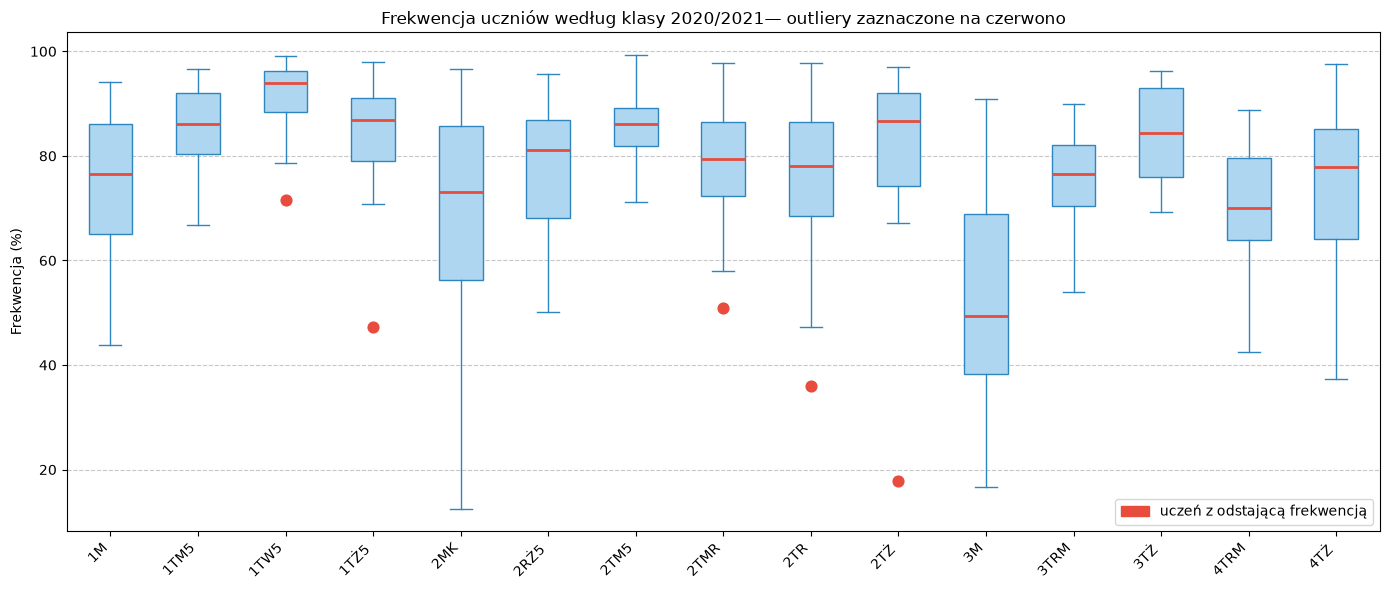

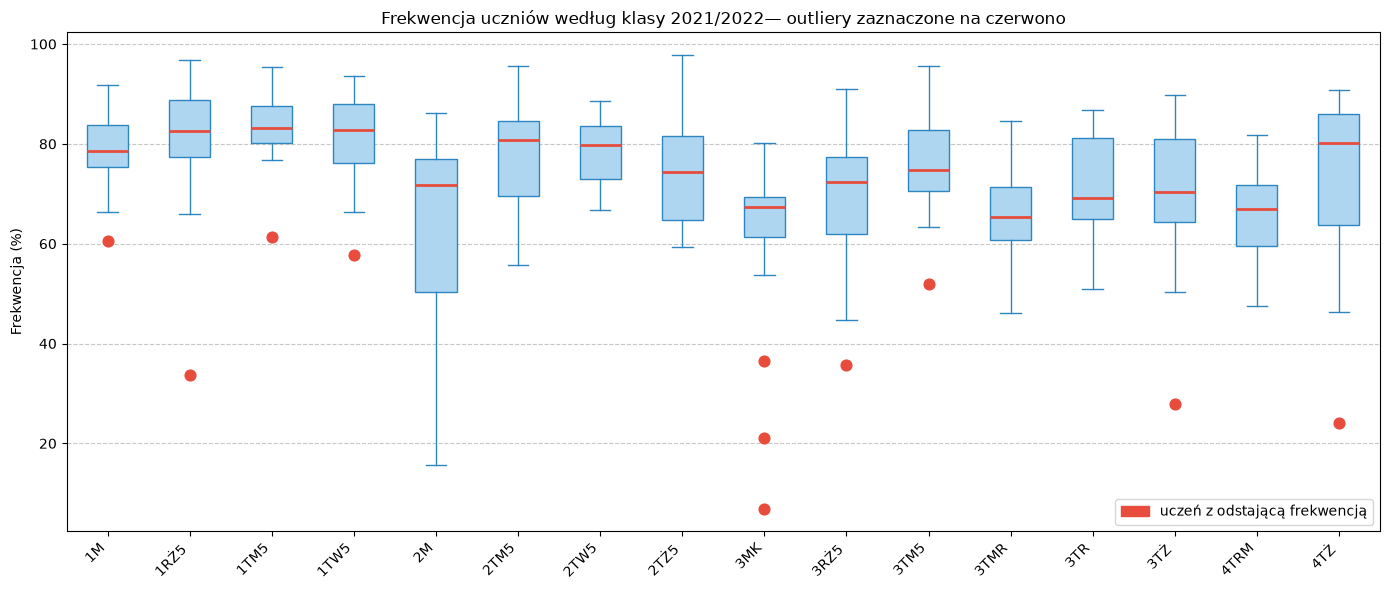

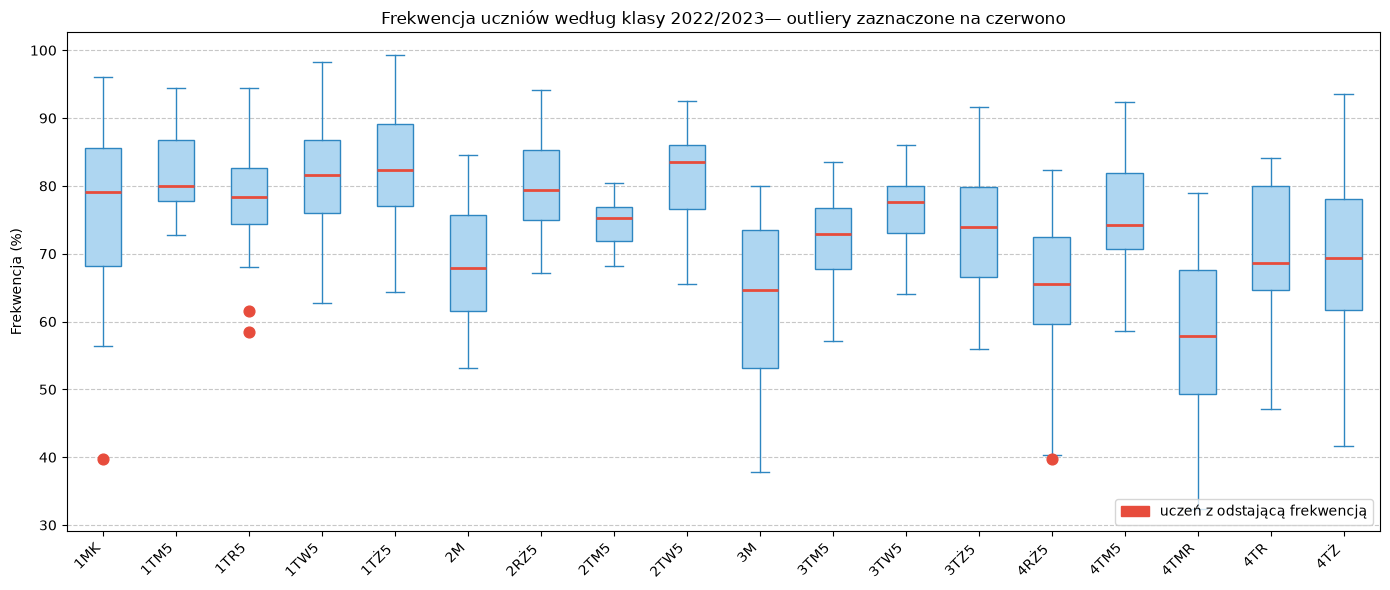

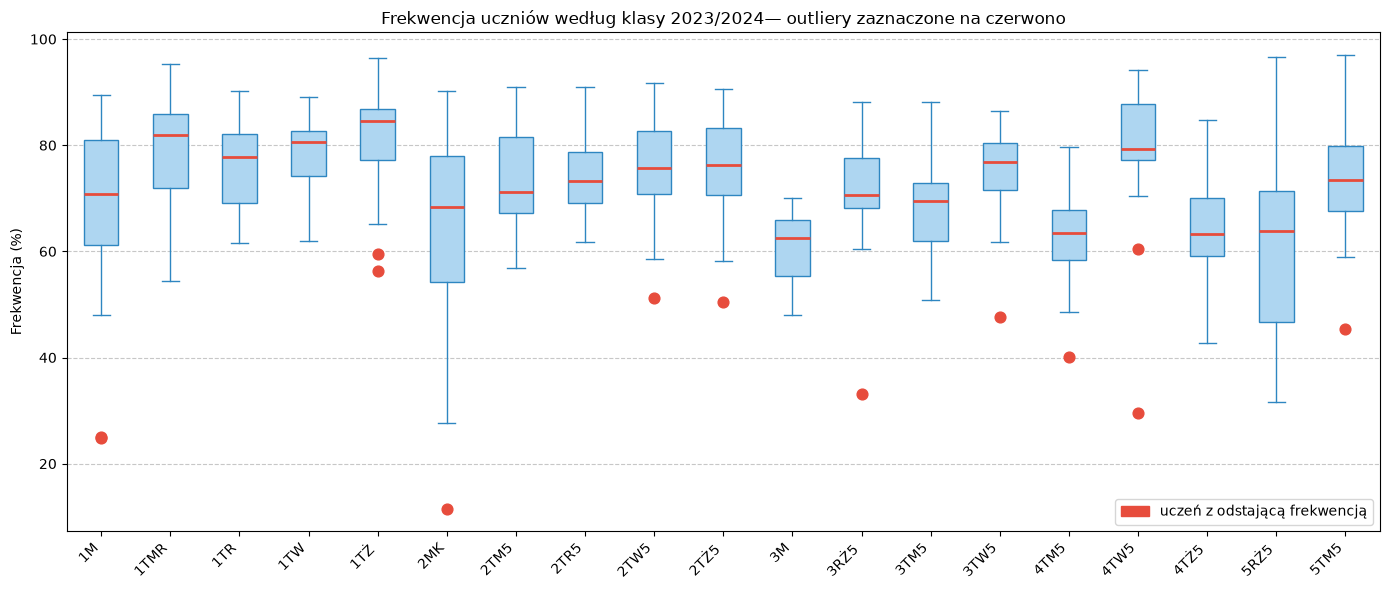

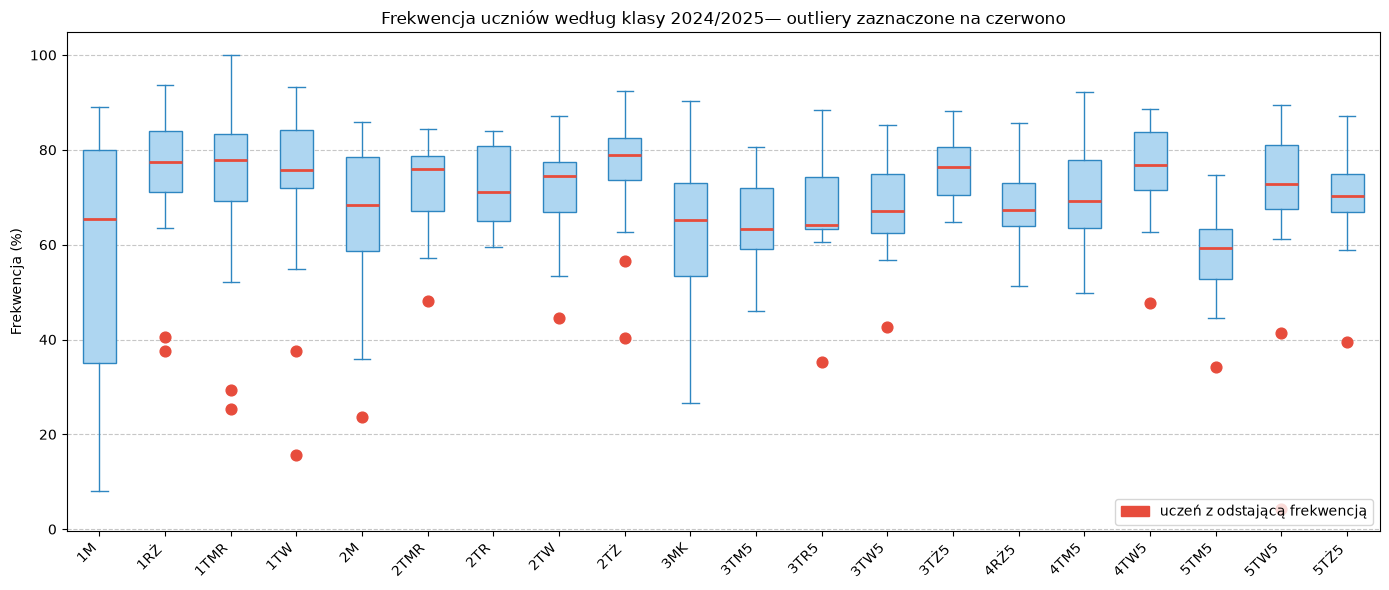

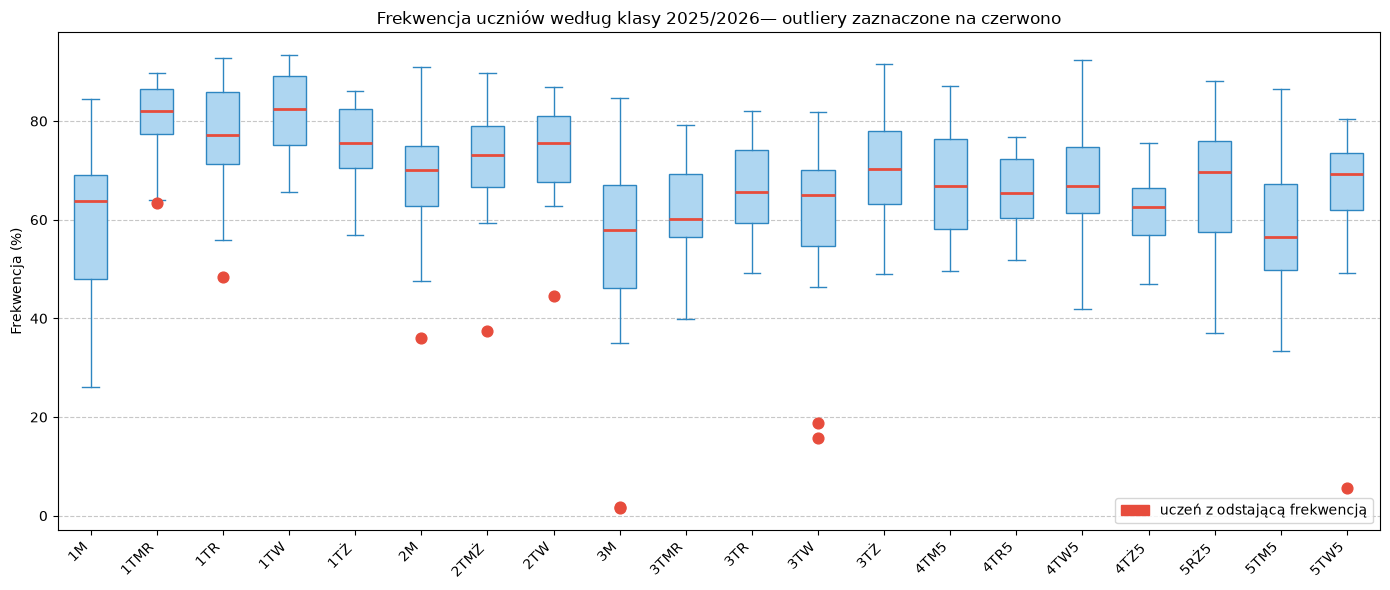

In [14]:
for frekwencja in frekwencja_list:
    Q1 = frekwencja.groupby("Dziennik")["frekwencja_pct"].transform("quantile", 0.25)
    Q3 = frekwencja.groupby("Dziennik")["frekwencja_pct"].transform("quantile", 0.75)
    dolna = Q1 - 1.5 * (Q3 - Q1)
    rok = frekwencja["rok_szkolny"].iloc[0]

    odstajacy_klasy = (
        frekwencja[frekwencja["frekwencja_pct"] < dolna]
        [["Dziennik", "uczen_id", "frekwencja_pct"]]
        .sort_values(["Dziennik", "frekwencja_pct"])
        .reset_index(drop=True)
    )


    klasy = frekwencja["Dziennik"].unique()
    klasy_sorted = sorted(klasy)
    fig, ax = plt.subplots(figsize=(14, 6))
    for i, klasa in enumerate(klasy_sorted):
        dane = frekwencja[frekwencja["Dziennik"] == klasa]["frekwencja_pct"]
        odstajace = odstajacy_klasy[odstajacy_klasy["Dziennik"] == klasa]["frekwencja_pct"]
        
        # Boxplot
        ax.boxplot(dane, positions=[i], widths=0.5,
                patch_artist=True,
                boxprops=dict(facecolor="#AED6F1", color="#2E86C1"),
                medianprops=dict(color="#E74C3C", linewidth=2),
                whiskerprops=dict(color="#2E86C1"),
                capprops=dict(color="#2E86C1"),
                flierprops=dict(marker=""))  # ukryj domyślne outliers
        
        # Outliersy na czerwono
        if len(odstajace) > 0:
            ax.scatter([i] * len(odstajace), odstajace,
                    color="#E74C3C", zorder=5, s=60, label="outlier" if i == 0 else "")

    ax.set_xticks(range(len(klasy_sorted)))
    ax.set_xticklabels(klasy_sorted, rotation=45, ha="right")
    ax.set_ylabel("Frekwencja (%)")
    ax.set_title(f"Frekwencja uczniów według klasy {rok}— outliery zaznaczone na czerwono")
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)

    czerwona_kropka = mpatches.Patch(color="#E74C3C", label="uczeń z odstającą frekwencją")
    ax.legend(handles=[czerwona_kropka], loc="lower right")

    plt.tight_layout()
    plt.show()

## Jaka by była frekwencja klasy bez odstających uczniów


In [15]:
# Uczniowie z odstającą frekwencją
for frekwencja in frekwencja_list:
    rok = frekwencja["rok_szkolny"].iloc[0]
    frekwencja_klasy = (
        frekwencja
        .groupby("Dziennik")["frekwencja_pct"]
        .mean()
        .round(1)
        .reset_index()
        .rename(columns={"frekwencja_pct": "frekwencja_%"})
    )

    Q1 = frekwencja.groupby("Dziennik")["frekwencja_pct"].transform("quantile", 0.25)
    Q3 = frekwencja.groupby("Dziennik")["frekwencja_pct"].transform("quantile", 0.75)
    dolna = Q1 - 1.5 * (Q3 - Q1)

    odstajacy = (
        frekwencja[frekwencja["frekwencja_pct"] < dolna]
        [["Dziennik", "uczen_id", "frekwencja_pct"]]
        .sort_values(["Dziennik", "frekwencja_pct"])
        .reset_index(drop=True)
    )
    odstajacy_ids = odstajacy[["Dziennik", "uczen_id"]]

    # Frekwencja bez odstających
    frekwencja_bez = (
        frekwencja
        .merge(odstajacy_ids, on=["Dziennik", "uczen_id"], how="left", indicator=True)
        .query('_merge == "left_only"')
        .drop(columns="_merge")
    )

    # Średnia klasy bez odstających
    frekwencja_klasy_bez = (
        frekwencja_bez
        .groupby("Dziennik")["frekwencja_pct"]
        .mean()
        .round(1)
        .reset_index()
        .rename(columns={"frekwencja_pct": "frekwencja_bez_odstajacych_%"})
    )

    # Porównanie
    porownanie = (
        frekwencja_klasy
        .merge(frekwencja_klasy_bez, on="Dziennik")
        .assign(roznica=lambda x: (x["frekwencja_bez_odstajacych_%"] - x["frekwencja_%"]).round(1))
        .sort_values("roznica", ascending=False)
    )
    print(f"\n=== {rok} — porównanie średniej frekwencji klasy z i bez odstających ===")
    display(porownanie)


=== 2020/2021 — porównanie średniej frekwencji klasy z i bez odstających ===


,Dziennik,frekwencja_%,frekwencja_bez_odstajacych_%,roznica
9,2TŻ,81.6,84.5,2.9
3,1TŻ5,83.2,85.7,2.5
8,2TR,75.4,77.8,2.4
2,1TW5,91.1,92.6,1.5
7,2TMR,78.6,79.9,1.3
0,1M,74.0,74.0,0.0
1,1TM5,85.2,85.2,0.0
4,2MK,70.8,70.8,0.0
5,2RŻ5,77.2,77.2,0.0
6,2TM5,85.0,85.0,0.0



=== 2021/2022 — porównanie średniej frekwencji klasy z i bez odstających ===


,Dziennik,frekwencja_%,frekwencja_bez_odstajacych_%,roznica
8,3MK,62.1,68.2,6.1
15,4TŻ,73.7,76.4,2.7
13,3TŻ,69.8,71.9,2.1
1,1RŻ5,81.0,82.7,1.7
0,1M,78.5,79.7,1.2
10,3TM5,76.4,77.6,1.2
9,3RŻ5,69.7,70.8,1.1
2,1TM5,83.1,84.1,1.0
3,1TW5,81.1,82.1,1.0
4,2M,61.9,61.9,0.0



=== 2022/2023 — porównanie średniej frekwencji klasy z i bez odstających ===


...

,Dziennik,frekwencja_%,frekwencja_bez_odstajacych_%,roznica
15,4TW5,77.6,83.5,5.9
0,1M,68.0,71.7,3.7
5,2MK,64.6,66.3,1.7
4,1TŻ,81.0,82.7,1.7
11,3RŻ5,71.6,73.1,1.5
18,5TM5,73.8,75.2,1.4
13,3TW5,75.1,76.4,1.3
14,4TM5,62.5,63.8,1.3
9,2TŻ5,75.3,76.5,1.2
8,2TW5,76.0,77.1,1.1



=== 2024/2025 — porównanie średniej frekwencji klasy z i bez odstających ===


,Dziennik,frekwencja_%,frekwencja_bez_odstajacych_%,roznica
18,5TW5,68.0,76.2,8.2
3,1TW,73.2,78.4,5.2
2,1TMR,73.5,78.1,4.6
1,1RŻ,74.8,79.0,4.2
19,5TŻ5,69.7,72.5,2.8
11,3TR5,67.7,70.0,2.3
8,2TŻ,76.5,78.7,2.2
4,2M,66.2,68.2,2.0
16,4TW5,75.9,77.3,1.4
17,5TM5,57.7,59.0,1.3



=== 2025/2026 — porównanie średniej frekwencji klasy z i bez odstających ===


,Dziennik,frekwencja_%,frekwencja_bez_odstajacych_%,roznica
8,3M,54.7,59.3,4.6
11,3TW,60.8,64.6,3.8
19,5TW5,65.5,68.2,2.7
5,2M,68.8,70.8,2.0
7,2TW,73.9,75.6,1.7
2,1TR,77.1,78.5,1.4
6,2TMŻ,72.6,73.9,1.3
1,1TMR,80.6,81.4,0.8
14,4TR5,65.6,65.6,0.0
18,5TM5,58.8,58.8,0.0


## Porównanie frekwencji klas przez lata

### Budowanie df_porownanie

In [16]:
def dziennik_na_rocznik(dziennik, rok_szkolny):
    """Oblicza rok rozpoczęcia nauki na podstawie numeru klasy i roku szkolnego."""
    rok_start = int(rok_szkolny.split("/")[0])
    numer = re.match(r"^(\d+)", str(dziennik))
    if numer:
        nr = int(numer.group(1))
        return rok_start - nr + 1
    return None

wszystkie_lata = []

for frekwencja in frekwencja_list:
    rok = frekwencja["rok_szkolny"].iloc[0]
    frekwencja_klasy = (
        frekwencja
        .groupby("Dziennik")["frekwencja_pct"]
        .mean()
        .round(1)
        .reset_index()
        .rename(columns={"frekwencja_pct": "frekwencja_%"})
    )
    frekwencja_klasy["rok_szkolny"] = rok
    wszystkie_lata.append(frekwencja_klasy)

df_porownanie = pd.concat(wszystkie_lata, ignore_index=True)
df_porownanie["rocznik"] = df_porownanie.apply(
    lambda r: dziennik_na_rocznik(r["Dziennik"], r["rok_szkolny"]), axis=1
)
df_porownanie["sufiks"] = df_porownanie["Dziennik"].str.extract(r"^\d+(.*)")
df_porownanie["rocznik_str"] = df_porownanie["rocznik"].astype(str)

df_porownanie.head()

,Dziennik,frekwencja_%,rok_szkolny,rocznik,sufiks,rocznik_str
0,1M,74.0,2020/2021,2020,M,2020
1,1TM5,85.2,2020/2021,2020,TM5,2020
2,1TW5,91.1,2020/2021,2020,TW5,2020
3,1TŻ5,83.2,2020/2021,2020,TŻ5,2020
4,2MK,70.8,2020/2021,2019,MK,2019


## Wykresy: każdy rocznik — klasy przez lata

In [17]:
for rocznik, grupa in df_porownanie.groupby("rocznik"):
    grupa = grupa.sort_values(["rok_szkolny", "sufiks"])

    fig = px.bar(
        grupa,
        x="rok_szkolny",
        y="frekwencja_%",
        color="sufiks",
        barmode="group",
        text="Dziennik",
        hover_data={"Dziennik": True, "frekwencja_%": True, "rocznik_str": True},
        title=f"Rocznik {rocznik} — frekwencja klas przez lata"
    )
    fig.update_traces(textangle=45, textposition="outside")
    fig.update_layout(
        yaxis_range=[50, 105],
        xaxis_title="Rok szkolny",
        yaxis_title="Frekwencja [%]",
        legend_title="Kierunek",
        height=500
    )
    fig.show()

## Wykresy: każdy kierunek — przez wszystkie lata i roczniki

In [18]:
for sufiks, grupa in df_porownanie.groupby("sufiks"):
    grupa = grupa.sort_values(["rok_szkolny", "rocznik"])

    fig = px.bar(
        grupa,
        x="rok_szkolny",
        y="frekwencja_%",
        color="rocznik_str",
        barmode="group",
        text="Dziennik",
        hover_data={"Dziennik": True, "frekwencja_%": True, "rocznik_str": True},
        title=f"Kierunek {sufiks} — frekwencja przez wszystkie lata"
    )
    fig.update_traces(textangle=45, textposition="outside")
    fig.update_layout(
        yaxis_range=[50, 105],
        xaxis_title="Rok szkolny",
        yaxis_title="Frekwencja [%]",
        legend_title="Rocznik",
        height=500
    )
    fig.show()
    

In [19]:
# Połącz surowe dane wszystkich lat z rocznikiem
df_all = pd.concat(df_list_, ignore_index=True)

# Dodaj numer dnia tygodnia
df_all["dzien_tygodnia"] = pd.to_datetime(df_all["Data lekcji"]).dt.dayofweek  # 0=pon, 4=pt

# Dodaj sufiks i rocznik
df_all["sufiks"] = df_all["Dziennik"].str.extract(r"^\d+(.*)")
df_all["rocznik"] = df_all.apply(
    lambda r: dziennik_na_rocznik(r["Dziennik"], r["rok_szkolny"]), axis=1
)

DNI = {0: "Poniedziałek", 1: "Wtorek", 2: "Środa", 3: "Czwartek", 4: "Piątek"}

# Frekwencja % per rocznik + dzień tygodnia (po wszystkich latach łącznie)
wpis_cols_nieob = ['wpis_nieob. uspr. p.s.', 'wpis_nieob. uspraw.', 'wpis_nieobecność']
wpis_cols_wszystkie = wpis_cols_nieob + [
    'wpis_nauka zdalna', 'wpis_obecność', 'wpis_spóźn. uspr.',
    'wpis_spóźnienie', 'wpis_zwolniony'
]

frekw_dzien_rok = (
    df_all
    .groupby(["rok_szkolny", "Dziennik", "dzien_tygodnia"])[wpis_cols_wszystkie]
    .sum()
    .assign(
        wszystkich     = lambda x: x[wpis_cols_wszystkie].sum(axis=1),
        nieobecnych    = lambda x: x[wpis_cols_nieob].sum(axis=1),
        frekwencja_pct = lambda x: ((x["wszystkich"] - x["nieobecnych"]) / x["wszystkich"] * 100).round(1)
    )
    .reset_index()
)
frekw_dzien_rok["dzien_nazwa"] = frekw_dzien_rok["dzien_tygodnia"].map(DNI)

for rok_szkolny, grupa in frekw_dzien_rok.groupby("rok_szkolny"):
    grupa = grupa.sort_values("dzien_tygodnia")

    maska_branzowa = grupa["Dziennik"].str.match(r"^\d+(M|MK|RŻ\d*)")
    branzowa = grupa[maska_branzowa]
    technikum = grupa[~maska_branzowa]

    for nazwa, podgrupa in [("Branżowa", branzowa), ("Technikum", technikum)]:
        if podgrupa.empty:
            continue
        n_klas = podgrupa["Dziennik"].nunique()

        fig = px.bar(
            podgrupa,
            x="dzien_nazwa",
            y="frekwencja_pct",
            color="Dziennik",
            barmode="group",
            text="frekwencja_pct",
            title=f"{rok_szkolny} — {nazwa} — frekwencja wg dnia tygodnia",
            labels={
                "dzien_nazwa": "Dzień tygodnia",
                "frekwencja_pct": "Frekwencja [%]",
                "Dziennik": "Klasa"
            },
            category_orders={
                "dzien_nazwa": ["Poniedziałek", "Wtorek", "Środa", "Czwartek", "Piątek"]
            }
        )
        fig.update_traces(textposition="outside", textangle=0, textfont_size=8)
        fig.update_layout(
            yaxis_range=[50, 90],
            height=500,
            width=min(300 + n_klas * 80, 1200),
            bargap=0.1,
            bargroupgap=0.05,
            legend=dict(orientation="v", x=1.02, y=1)
        )
        fig.show()

        # Tabela pod wykresem
        tabela = (
            podgrupa
            .pivot(index="Dziennik", columns="dzien_nazwa", values="frekwencja_pct")
            .reindex(columns=["Poniedziałek", "Wtorek", "Środa", "Czwartek", "Piątek"])
            .sort_index()
        )
        tabela.columns.name = None
        tabela.index.name = "Klasa"
        tabela["Średnia"] = tabela.mean(axis=1).round(1)
        display(tabela)

,Poniedziałek,Wtorek,Środa,Czwartek,Piątek,Średnia
Klasa,,,,,,
1M,72.8,72.8,77.6,72.7,74.6,74.1
2MK,60.6,58.7,75.2,69.7,69.6,66.8
2RŻ5,73.6,77.9,75.8,74.9,81.3,76.7
3M,54.0,55.8,48.1,46.5,58.3,52.5


,Poniedziałek,Wtorek,Środa,Czwartek,Piątek,Średnia
Klasa,,,,,,
1TM5,73.8,88.7,86.0,81.4,83.9,82.8
1TW5,91.1,90.2,93.4,89.5,90.4,90.9
1TŻ5,83.5,89.5,82.4,81.8,81.3,83.7
2TM5,87.4,82.5,84.0,85.5,83.4,84.6
2TMR,79.4,80.2,79.5,78.6,75.3,78.6
2TR,76.6,76.9,80.5,73.6,69.2,75.4
2TŻ,85.5,85.9,83.0,84.3,76.7,83.1
3TRM,77.9,78.4,74.9,72.4,78.0,76.3
3TŻ,84.8,83.8,80.0,84.6,87.0,84.0


,Poniedziałek,Wtorek,Środa,Czwartek,Piątek,Średnia
Klasa,,,,,,
1M,78.6,78.0,82.0,79.2,71.7,77.9
1RŻ5,80.8,85.8,81.6,78.2,77.6,80.8
2M,61.1,67.6,61.6,65.2,57.2,62.5
3MK,50.8,69.1,64.1,62.9,62.4,61.9
3RŻ5,70.7,71.6,70.8,47.2,68.3,65.7


,Poniedziałek,Wtorek,Środa,Czwartek,Piątek,Średnia
Klasa,,,,,,
1TM5,83.9,85.3,81.9,87.2,77.1,83.1
1TW5,79.0,83.2,81.2,80.5,80.9,81.0
2TM5,78.4,81.3,79.2,79.6,62.7,76.2
2TW5,78.4,79.4,80.7,76.1,78.0,78.5
2TŻ5,71.6,79.3,78.4,74.9,72.1,75.3
3TM5,75.5,80.4,75.4,75.0,74.7,76.2
3TMR,64.5,71.1,64.3,63.0,67.9,66.2
3TR,75.1,72.3,74.0,67.2,68.1,71.3
3TŻ,68.9,73.0,72.4,73.7,63.2,70.2


,Poniedziałek,Wtorek,Środa,Czwartek,Piątek,Średnia
Klasa,,,,,,
1MK,78.9,78.7,76.1,75.6,79.2,77.7
2M,66.3,72.6,69.2,70.9,64.3,68.7
2RŻ5,80.3,81.9,81.9,78.7,72.6,79.1
3M,62.5,61.6,71.4,61.0,54.9,62.3
4RŻ5,67.1,68.7,64.6,62.8,62.0,65.0


...

,Poniedziałek,Wtorek,Środa,Czwartek,Piątek,Średnia
Klasa,,,,,,
1TMR,85.0,76.8,80.1,74.5,75.5,78.4
1TR,84.4,77.9,77.0,74.8,69.8,76.8
1TW,81.2,80.1,78.8,74.6,76.9,78.3
1TŻ,83.3,83.2,85.6,75.3,76.6,80.8
2TM5,82.3,78.4,71.2,67.2,64.6,72.7
2TR5,79.3,73.7,75.3,70.2,71.7,74.0
2TW5,80.8,78.2,78.5,69.4,72.0,75.8
2TŻ5,79.1,76.5,78.0,73.7,69.7,75.4
3TM5,69.2,70.8,71.2,66.2,63.8,68.2


,Poniedziałek,Wtorek,Środa,Czwartek,Piątek,Średnia
Klasa,,,,,,
1M,73.5,72.3,69.5,68.2,66.7,70.0
1RŻ,72.8,77.2,76.6,77.0,65.6,73.8
2M,68.1,69.9,65.5,66.3,61.7,66.3
3MK,60.6,74.7,56.9,61.1,54.0,61.5
4RŻ5,72.2,70.2,66.6,69.7,58.6,67.5


,Poniedziałek,Wtorek,Środa,Czwartek,Piątek,Średnia
Klasa,,,,,,
1TMR,80.7,82.1,80.0,80.7,68.2,78.3
1TW,79.3,83.5,78.0,77.3,70.5,77.7
2TMR,73.3,73.9,76.7,69.0,71.5,72.9
2TR,73.1,78.0,71.8,68.4,67.9,71.8
2TW,71.6,71.9,73.5,69.5,68.5,71.0
2TŻ,77.4,79.6,78.5,76.3,72.0,76.8
3TM5,71.1,69.3,57.2,68.4,57.4,64.7
3TR5,72.1,69.3,71.0,66.5,57.9,67.4
3TW5,72.5,68.0,69.8,65.0,63.9,67.8


,Poniedziałek,Wtorek,Środa,Czwartek,Piątek,Średnia
Klasa,,,,,,
1M,65.6,60.0,63.6,61.1,50.6,60.2
2M,76.5,68.8,73.6,70.0,64.1,70.6
3M,58.7,60.5,60.2,59.0,55.3,58.7
5RŻ5,66.9,70.7,68.5,69.1,60.2,67.1


,Poniedziałek,Wtorek,Środa,Czwartek,Piątek,Średnia
Klasa,,,,,,
1TMR,83.3,83.4,84.4,79.9,73.2,80.8
1TR,81.0,81.0,80.2,80.1,67.5,78.0
1TW,84.8,85.6,81.0,81.5,75.1,81.6
1TŻ,76.8,79.3,77.4,70.6,68.5,74.5
2TMŻ,77.2,78.0,75.0,71.5,64.4,73.2
2TW,75.0,76.4,78.4,72.9,66.9,73.9
3TMR,64.1,67.1,60.2,60.3,58.9,62.1
3TR,70.0,70.8,68.9,65.0,54.4,65.8
3TW,68.0,68.6,67.4,57.6,49.7,62.3


In [20]:
print(df_all[df_all["rok_szkolny"] == "2025/2026"][["Dziennik", "rocznik"]].drop_duplicates().sort_values("Dziennik"))

        Dziennik  rocznik
2531217       1M     2025
2111188     1TMR     2025
2139566      1TR     2025
2163858      1TW     2025
2195823      1TŻ     2025
2549644       2M     2024
2225886     2TMŻ     2024
2259506      2TW     2024
2568284       3M     2023
2281521     3TMR     2023
2308995      3TR     2023
2334310      3TW     2023
2364883      3TŻ     2023
2395665     4TM5     2022
2417404     4TR5     2022
2433638     4TW5     2022
2457682     4TŻ5     2022
2477775     5RŻ5     2021
2496273     5TM5     2021
2513902     5TW5     2021


In [21]:
print(df_all.groupby("rocznik")["Dziennik"].nunique().sort_index())

rocznik
2017     2
2018     5
2019    19
2020    18
2021    18
2022    19
2023    15
2024     7
2025     5
Name: Dziennik, dtype: int64


#  Co ma wpływ na frekwencję . Jakie lekcje są w kazdej opuszczane , jakie dni ,

## Frekwencja w kazdy dzień tygodnia

In [22]:

frekwencja_list[0]

,rok_szkolny,Dziennik,uczen_id,wpis_nieob. uspr. p.s.,wpis_nieob. uspraw.,wpis_nieobecność,wpis_nauka zdalna,wpis_obecność,wpis_spóźn. uspr.,wpis_spóźnienie,wpis_zwolniony,wszystkich,nieobecnych,frekwencja_pct
0,2020/2021,1M,08B5634E90,3,97,19,672,360,0,1,0,1152,119,89.7
1,2020/2021,1M,1353AF652A,0,52,479,339,276,0,6,0,1152,531,53.9
2,2020/2021,1M,2072B8A93F,0,246,311,434,157,1,2,1,1152,557,51.6
3,2020/2021,1M,2749F8FF3A,0,28,189,614,319,0,2,0,1152,217,81.2
4,2020/2021,1M,27505A1520,0,44,271,618,216,0,1,2,1152,315,72.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,2020/2021,4TŻ,CD18D65DC2,80,87,93,585,119,0,5,0,969,260,73.2
308,2020/2021,4TŻ,D1998C1E01,7,64,281,490,131,0,8,0,981,352,64.1
309,2020/2021,4TŻ,D36E445159,6,87,7,618,259,1,0,0,978,100,89.8
310,2020/2021,4TŻ,E18F8FA243,23,120,1,602,216,2,0,3,967,144,85.1


In [23]:
DNI_KOLEJNOSC = ["Poniedziałek", "Wtorek", "Środa", "Czwartek", "Piątek"]

maska_branzowa = frekw_dzien_rok["Dziennik"].str.match(r"^\d+(M|MK|RŻ\d*)")

for nazwa, podgrupa in [("Branżowa", frekw_dzien_rok[maska_branzowa]),
                         ("Technikum", frekw_dzien_rok[~maska_branzowa])]:
    if podgrupa.empty:
        continue

    klasy_sorted = sorted(podgrupa["Dziennik"].unique())

    fig = px.line(
        podgrupa,
        x="dzien_nazwa", y="frekwencja_pct", color="rok_szkolny",
        facet_col="Dziennik", facet_col_wrap=4,
        category_orders={"dzien_nazwa": DNI_KOLEJNOSC, "Dziennik": klasy_sorted},
        markers=True,
        title=f"{nazwa} — frekwencja wg dnia tygodnia, każda klasa i każdy rok szkolny",
        labels={"dzien_nazwa": "Dzień tygodnia", "frekwencja_pct": "Frekwencja [%]", "rok_szkolny": "Rok szkolny"}
    )
    fig.update_yaxes(range=[50, 100])
    fig.update_xaxes(tickangle=45)
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))  # usuń "Dziennik=" z tytułów paneli

    n_rows = -(-len(klasy_sorted) // 4)  # zaokrąglenie w górę
    fig.update_layout(height=280 * n_rows, legend_title="Rok szkolny")
    fig.show()


### Frekwencja tej samej grupy uczniów (kohorty) wg dnia tygodnia, przez wszystkie lata ich nauki
"Kohorta" = rocznik + kierunek (np. **Rocznik 2021 (TM)** = ta sama grupa uczniów, która zaczynęła jako 1TM w 2021/2022 i szła przez 2TM, 3TM... aż do maks. klasy). Jedna heatmapa na kohortę: wiersze = kolejny rok nauki (klasa 1, 2, 3...), kolumny = dzień tygodnia — dzięki temu widać czy np. frekwencja w piątki pogarsza się wraz z wiekiem uczniów, niezależnie od tego w którym roku kalendarzowym to było.


In [24]:
DNI_KOLEJNOSC = ["Poniedziałek", "Wtorek", "Środa", "Czwartek", "Piątek"]

def numer_klasy(dziennik):
    numer = re.match(r"^(\d+)", str(dziennik))
    return int(numer.group(1)) if numer else None

# frekw_dzien_rok już ma rok_szkolny / Dziennik / dzien_nazwa / frekwencja_pct (z komórki wyżej)
frekw_kohorta = frekw_dzien_rok.copy()
frekw_kohorta["rocznik"] = frekw_kohorta.apply(
    lambda r: dziennik_na_rocznik(r["Dziennik"], r["rok_szkolny"]), axis=1
)
frekw_kohorta["sufiks"] = frekw_kohorta["Dziennik"].str.extract(r"^\d+(.*)")
frekw_kohorta["numer_klasy"] = frekw_kohorta["Dziennik"].apply(numer_klasy)
frekw_kohorta["kohorta"] = "Rocznik " + frekw_kohorta["rocznik"].astype(str) + " (" + frekw_kohorta["sufiks"] + ")"

for kohorta, grupa in frekw_kohorta.groupby("kohorta"):
    if grupa["numer_klasy"].nunique() < 2:
        continue  # pomiń kohorty z tylko jednym rokiem danych - nic do porównania

    pivot = (
        grupa.pivot_table(index="numer_klasy", columns="dzien_nazwa", values="frekwencja_pct", aggfunc="mean")
        .reindex(columns=DNI_KOLEJNOSC)
        .sort_index()
    )
    # etykiety wierszy: "Klasa 1 (2021/2022)" itd.
    etykiety_lat = grupa.sort_values("numer_klasy").groupby("numer_klasy")["rok_szkolny"].first()
    pivot.index = [f"Klasa {n} ({etykiety_lat[n]})" for n in pivot.index]

    fig = go.Figure(data=go.Heatmap(
        z=pivot.values, x=pivot.columns, y=pivot.index,
        colorscale=[[0, "#A8433A"], [0.5, "#F0EADA"], [1, "#4C7A6B"]],
        zmid=85, zmin=50, zmax=100,
        text=pivot.values, texttemplate="%{text:.1f}",
        colorbar=dict(title="Frekwencja %"),
        hovertemplate="%{y}<br>%{x}: %{z:.1f}%<extra></extra>"
    ))
    fig.update_layout(
        title=f"{kohorta} — frekwencja wg dnia tygodnia, każdy rok nauki",
        height=90 + 40 * len(pivot),
        margin=dict(t=60, l=140, r=20, b=40)
    )
    fig.show()


## Frekwencja wg przedmiotu — jakie lekcje są opuszczane
Używa `df_all` i list `wpis_cols_nieob` / `wpis_cols_wszystkie` zdefiniowanych w komórce z `frekw_dzien_rok` powyżej. Przedmioty z małą liczbą wpisów (np. nadobowiązkowe, jednosemestralne) są odfiltrowane, żeby nie zaburzać rankingu pojedynczymi przypadkami.

In [25]:
PROG_MIN_WPISOW = 200  # przedmioty z mniejszą liczbą wpisów pomijamy w rankingu - zbyt niepewny wynik

# --- Ranking ogólny: frekwencja wg przedmiotu, suma po wszystkich latach ---
ranking_przedmioty = (
    df_all.groupby("Przedmiot")[wpis_cols_wszystkie].sum()
    .assign(
        wszystkich=lambda x: x[wpis_cols_wszystkie].sum(axis=1),
        nieobecnych=lambda x: x[wpis_cols_nieob].sum(axis=1),
        frekwencja_pct=lambda x: ((x["wszystkich"] - x["nieobecnych"]) / x["wszystkich"] * 100).round(1)
    )[["wszystkich", "nieobecnych", "frekwencja_pct"]]
    .query("wszystkich >= @PROG_MIN_WPISOW")
    .sort_values("frekwencja_pct")
)

fig = px.bar(
    ranking_przedmioty.reset_index(),
    x="frekwencja_pct", y="Przedmiot", orientation="h",
    text="frekwencja_pct",
    hover_data={"wszystkich": True, "nieobecnych": True},
    title=f"Frekwencja wg przedmiotu — wszystkie lata razem (min. {PROG_MIN_WPISOW} wpisów)",
    labels={"frekwencja_pct": "Frekwencja [%]", "Przedmiot": ""}
)
fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_range=[0, 105],
    height=max(400, 28 * len(ranking_przedmioty)),
    yaxis={"categoryorder": "total ascending"}
)
fig.show()

display(ranking_przedmioty)

# --- Trend przedmiotu przez lata: heatmapa Przedmiot x rok_szkolny ---
przedmioty_do_pokazania = ranking_przedmioty.index.tolist()  # te same co w rankingu (po odfiltrowaniu)

trend_przedmioty = (
    df_all[df_all["Przedmiot"].isin(przedmioty_do_pokazania)]
    .groupby(["Przedmiot", "rok_szkolny"])[wpis_cols_wszystkie].sum()
    .assign(
        wszystkich=lambda x: x[wpis_cols_wszystkie].sum(axis=1),
        nieobecnych=lambda x: x[wpis_cols_nieob].sum(axis=1),
        frekwencja_pct=lambda x: ((x["wszystkich"] - x["nieobecnych"]) / x["wszystkich"] * 100).round(1)
    )
    .reset_index()
)

pivot_przedmioty = (
    trend_przedmioty.pivot(index="Przedmiot", columns="rok_szkolny", values="frekwencja_pct")
    .reindex(index=ranking_przedmioty.index)  # zachowaj kolejność z rankingu (najgorsze na górze)
)

fig2 = go.Figure(data=go.Heatmap(
    z=pivot_przedmioty.values, x=pivot_przedmioty.columns, y=pivot_przedmioty.index,
    colorscale=[[0, "#A8433A"], [0.5, "#F0EADA"], [1, "#4C7A6B"]],
    zmid=85, zmin=50, zmax=100,
    text=pivot_przedmioty.values, texttemplate="%{text:.1f}",
    colorbar=dict(title="Frekwencja %"),
    hovertemplate="%{y}<br>%{x}: %{z:.1f}%<extra></extra>"
))
fig2.update_layout(
    title="Frekwencja wg przedmiotu — trend przez lata",
    height=80 + 32 * len(pivot_przedmioty),
    margin=dict(t=60, l=180, r=20, b=40)
)
fig2.show()


,wszystkich,nieobecnych,frekwencja_pct
Przedmiot,,,
Język niemiecki zawodowy (z_j_niemiecki),3760,1597,57.5
Wiedza o społeczeństwie (wos),11187,4075,63.6
Działalność gospodarcza (DzG),7315,2634,64.0
Integrowana ochrona roślin (IOR),8589,2865,66.6
Działalność gospodarcza w branży mechaniczno-rolniczej (DzGwBMR),3332,1102,66.9
...,...,...,...
Anatomia i fizjologia zwierząt (Anatomia),12642,2493,80.3
Chów zwierząt (CHZ),13808,2524,81.7
Bezpieczeństwo i higiena pracy (Bhp),12124,2188,82.0


## Frekwencja wg numeru pory lekcji — czy pierwsza i ostatnia lekcja są gorsze
Używa `df_all` i tych samych list `wpis_cols_nieob` / `wpis_cols_wszystkie` co analiza przedmiotów wyżej. W przeciwieństwie do rankingu przedmiotów, tutaj kolejność na wykresie jest **naturalna** (1, 2, 3...), nie posortowana wg wartości — bo chcemy zobaczyć kształt krzywej w ciągu dnia, nie ranking.

In [26]:
PROG_MIN_WPISOW = 200  # przedmioty z mniejszą liczbą wpisów pomijamy w rankingu - zbyt niepewny wynik

# --- Ranking ogólny: frekwencja wg przedmiotu, suma po wszystkich latach ---
ranking_przedmioty = (
    df_all.groupby("Przedmiot")[wpis_cols_wszystkie].sum()
    .assign(
        wszystkich=lambda x: x[wpis_cols_wszystkie].sum(axis=1),
        nieobecnych=lambda x: x[wpis_cols_nieob].sum(axis=1),
        frekwencja_pct=lambda x: ((x["wszystkich"] - x["nieobecnych"]) / x["wszystkich"] * 100).round(1)
    )[["wszystkich", "nieobecnych", "frekwencja_pct"]]
    .query("wszystkich >= @PROG_MIN_WPISOW")
    .sort_values("frekwencja_pct")
)

fig = px.bar(
    ranking_przedmioty.reset_index(),
    x="frekwencja_pct", y="Przedmiot", orientation="h",
    text="frekwencja_pct",
    hover_data={"wszystkich": True, "nieobecnych": True},
    title=f"Frekwencja wg przedmiotu — wszystkie lata razem (min. {PROG_MIN_WPISOW} wpisów)",
    labels={"frekwencja_pct": "Frekwencja [%]", "Przedmiot": ""}
)
fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_range=[0, 105],
    height=max(400, 28 * len(ranking_przedmioty)),
    yaxis={"categoryorder": "total ascending"}
)
fig.show()

display(ranking_przedmioty)

# --- Trend przedmiotu przez lata: heatmapa Przedmiot x rok_szkolny ---
przedmioty_do_pokazania = ranking_przedmioty.index.tolist()  # te same co w rankingu (po odfiltrowaniu)

trend_przedmioty = (
    df_all[df_all["Przedmiot"].isin(przedmioty_do_pokazania)]
    .groupby(["Przedmiot", "rok_szkolny"])[wpis_cols_wszystkie].sum()
    .assign(
        wszystkich=lambda x: x[wpis_cols_wszystkie].sum(axis=1),
        nieobecnych=lambda x: x[wpis_cols_nieob].sum(axis=1),
        frekwencja_pct=lambda x: ((x["wszystkich"] - x["nieobecnych"]) / x["wszystkich"] * 100).round(1)
    )
    .reset_index()
)

pivot_przedmioty = (
    trend_przedmioty.pivot(index="Przedmiot", columns="rok_szkolny", values="frekwencja_pct")
    .reindex(index=ranking_przedmioty.index)  # zachowaj kolejność z rankingu (najgorsze na górze)
)

fig2 = go.Figure(data=go.Heatmap(
    z=pivot_przedmioty.values, x=pivot_przedmioty.columns, y=pivot_przedmioty.index,
    colorscale=[[0, "#A8433A"], [0.5, "#F0EADA"], [1, "#4C7A6B"]],
    zmid=85, zmin=50, zmax=100,
    text=pivot_przedmioty.values, texttemplate="%{text:.1f}",
    colorbar=dict(title="Frekwencja %"),
    hovertemplate="%{y}<br>%{x}: %{z:.1f}%<extra></extra>"
))
fig2.update_layout(
    title="Frekwencja wg przedmiotu — trend przez lata",
    height=80 + 32 * len(pivot_przedmioty),
    margin=dict(t=60, l=180, r=20, b=40)
)
fig2.show()


,wszystkich,nieobecnych,frekwencja_pct
Przedmiot,,,
Język niemiecki zawodowy (z_j_niemiecki),3760,1597,57.5
Wiedza o społeczeństwie (wos),11187,4075,63.6
Działalność gospodarcza (DzG),7315,2634,64.0
Integrowana ochrona roślin (IOR),8589,2865,66.6
Działalność gospodarcza w branży mechaniczno-rolniczej (DzGwBMR),3332,1102,66.9
...,...,...,...
Anatomia i fizjologia zwierząt (Anatomia),12642,2493,80.3
Chów zwierząt (CHZ),13808,2524,81.7
Bezpieczeństwo i higiena pracy (Bhp),12124,2188,82.0


## Dashboard dla dyrekcji (HTML) — kompletna wersja
Jeden samodzielny plik HTML na każdy rok szkolny. Sekcje: KPI, trendy wieloletnie (rocznik + kierunek), rozkład frekwencji i odstający (boxplot), ranking klas, alerty, frekwencja wg dnia tygodnia, wg przedmiotu, wg numeru pory lekcji. Nawigacja między latami i sekcjami wbudowana w każdy plik.

Korzysta z `frekwencja_list`, `df_porownanie`, `df_all` policzonych w komórkach powyżej. Wymaga `plotly` (już używanej).


In [27]:
"""
Kompletny dashboard frekwencji dla dyrekcji — jeden plik HTML na rok szkolny.
Sekcje: KPI, trendy wieloletnie, rozkład i odstający, ranking klas, alerty,
        dzień tygodnia, przedmiot, numer pory lekcji.
"""
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime
import pickle


PROG_ALERT = 85.0
PROG_MIN_WPISOW = 200
DNI_KOLEJNOSC = ["Poniedziałek", "Wtorek", "Środa", "Czwartek", "Piątek"]

KOLOR_DOBRA, KOLOR_UWAGA, KOLOR_ALARM = "#4C7A6B", "#C98A2C", "#A8433A"
KOLOR_NAVY, KOLOR_PAPIER, KOLOR_LINIA, KOLOR_TEKST2 = "#1C2B42", "#F6F3EC", "#DCD5C4", "#5B5F66"

def kolor_dla(pct):
    if pct >= 90: return KOLOR_DOBRA
    if pct >= PROG_ALERT: return KOLOR_UWAGA
    return KOLOR_ALARM

lata_posortowane = sorted(df_porownanie["rok_szkolny"].unique())

# --- Odstający (IQR), wszystkie lata naraz ---
odstajacy_wszystkie = []
for frekwencja in frekwencja_list:
    rok = frekwencja["rok_szkolny"].iloc[0]
    Q1 = frekwencja.groupby("Dziennik")["frekwencja_pct"].transform("quantile", 0.25)
    Q3 = frekwencja.groupby("Dziennik")["frekwencja_pct"].transform("quantile", 0.75)
    dolna = Q1 - 1.5 * (Q3 - Q1)
    odst = frekwencja[frekwencja["frekwencja_pct"] < dolna][["Dziennik", "uczen_id", "frekwencja_pct"]].copy()
    odst["rok_szkolny"] = rok
    odstajacy_wszystkie.append(odst)
odstajacy_all = pd.concat(odstajacy_wszystkie, ignore_index=True)


def linechart(df, grupa_col, tytul, podswietl_rok):
    fig = go.Figure()
    palette = ["#1C2B42","#4C7A6B","#C98A2C","#A8433A","#7C6A9C","#3E7CB1","#8C8266","#5B5F66"]
    grupy = sorted(df[grupa_col].dropna().unique(), key=lambda x: str(x))
    for i, g in enumerate(grupy):
        sub = df[df[grupa_col] == g].groupby("rok_szkolny")["frekwencja_%"].mean().reindex(lata_posortowane)
        fig.add_trace(go.Scatter(x=lata_posortowane, y=sub.values, mode="lines+markers", name=str(g),
                                  line=dict(width=2.5, color=palette[i % len(palette)]), marker=dict(size=6)))
    fig.add_vline(x=podswietl_rok, line_width=14, line_color="rgba(28,43,66,0.07)")
    fig.update_layout(
        title=dict(text=tytul, font=dict(family="Lora, serif", size=17, color=KOLOR_NAVY)),
        paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
        font=dict(family="Inter, sans-serif", size=12, color=KOLOR_TEKST2),
        margin=dict(t=50, l=40, r=20, b=40), height=340,
        yaxis=dict(title="Frekwencja [%]", gridcolor=KOLOR_LINIA, range=[50,100]),
        xaxis=dict(gridcolor=KOLOR_LINIA), legend=dict(orientation="h", y=-0.2, font=dict(size=10)),
        hovermode="x unified"
    )
    return fig


def boxplot_odstajacych(frekwencja_rok, rok):
    klasy = sorted(frekwencja_rok["Dziennik"].unique())
    fig = go.Figure()
    for klasa in klasy:
        sub = frekwencja_rok[frekwencja_rok["Dziennik"] == klasa]["frekwencja_pct"]
        fig.add_trace(go.Box(y=sub, name=klasa, boxpoints="outliers",
                              marker=dict(color=KOLOR_ALARM, size=5, opacity=0.85),
                              line=dict(color=KOLOR_NAVY, width=1.5),
                              fillcolor="rgba(28,43,66,0.06)", whiskerwidth=0.5))
    fig.update_layout(
        title=dict(text=f"Rozkład frekwencji uczniów w klasach — {rok} (punkty = odstający wg IQR)",
                   font=dict(family="Lora, serif", size=17, color=KOLOR_NAVY)),
        paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
        font=dict(family="Inter, sans-serif", size=12, color=KOLOR_TEKST2),
        margin=dict(t=50, l=40, r=20, b=40), height=420, showlegend=False,
        yaxis=dict(title="Frekwencja [%]", gridcolor=KOLOR_LINIA), xaxis=dict(gridcolor=KOLOR_LINIA),
    )
    return fig


DNI_MAPA = {0: "Poniedziałek", 1: "Wtorek", 2: "Środa", 3: "Czwartek", 4: "Piątek"}

def dzien_tygodnia_heatmap(df_all_rok, rok):
    """Heatmapa klasa x dzień tygodnia dla wybranego roku (cała szkoła, jeden wykres)."""
    df_all_rok = df_all_rok.copy()
    if "dzien_nazwa" not in df_all_rok.columns:
        # df_all ma tylko numeryczną "dzien_tygodnia" (0=pon...4=pt) - dolicz nazwę tutaj
        df_all_rok["dzien_nazwa"] = df_all_rok["dzien_tygodnia"].map(DNI_MAPA)
    agg = (
        df_all_rok.groupby(["Dziennik", "dzien_nazwa"])[wpis_cols_wszystkie].sum()
        .assign(wszystkich=lambda x: x[wpis_cols_wszystkie].sum(axis=1),
                nieobecnych=lambda x: x[wpis_cols_nieob].sum(axis=1),
                frekwencja_pct=lambda x: ((x["wszystkich"]-x["nieobecnych"])/x["wszystkich"]*100).round(1))
        .reset_index()
    )
    pivot = agg.pivot(index="Dziennik", columns="dzien_nazwa", values="frekwencja_pct").reindex(columns=DNI_KOLEJNOSC).sort_index()
    fig = go.Figure(data=go.Heatmap(
        z=pivot.values, x=pivot.columns, y=pivot.index,
        colorscale=[[0, KOLOR_ALARM], [0.5, "#F0EADA"], [1, KOLOR_DOBRA]], zmid=85, zmin=50, zmax=100,
        text=pivot.values, texttemplate="%{text:.1f}", colorbar=dict(title="Frekwencja %"),
        hovertemplate="Klasa %{y}<br>%{x}: %{z:.1f}%<extra></extra>"
    ))
    fig.update_layout(
        title=dict(text=f"Frekwencja wg dnia tygodnia — {rok} (wszystkie klasy)",
                   font=dict(family="Lora, serif", size=17, color=KOLOR_NAVY)),
        font=dict(family="Inter, sans-serif", size=11, color=KOLOR_TEKST2),
        height=80 + 26*len(pivot), margin=dict(t=50, l=80, r=20, b=40)
    )
    return fig


def przedmiot_ranking(df_all_rok, rok):
    """Ranking frekwencji wg przedmiotu, dla wybranego roku."""
    ranking = (
        df_all_rok.groupby("Przedmiot")[wpis_cols_wszystkie].sum()
        .assign(wszystkich=lambda x: x[wpis_cols_wszystkie].sum(axis=1),
                nieobecnych=lambda x: x[wpis_cols_nieob].sum(axis=1),
                frekwencja_pct=lambda x: ((x["wszystkich"]-x["nieobecnych"])/x["wszystkich"]*100).round(1))
        [["wszystkich", "nieobecnych", "frekwencja_pct"]]
        .query("wszystkich >= @PROG_MIN_WPISOW")
        .sort_values("frekwencja_pct")
    )
    fig = px.bar(ranking.reset_index(), x="frekwencja_pct", y="Przedmiot", orientation="h", text="frekwencja_pct",
                 hover_data={"wszystkich": True, "nieobecnych": True},
                 title=f"Frekwencja wg przedmiotu — {rok} (min. {PROG_MIN_WPISOW} wpisów)",
                 labels={"frekwencja_pct": "Frekwencja [%]", "Przedmiot": ""})
    fig.update_traces(textposition="outside", marker_color=KOLOR_NAVY)
    fig.update_layout(
        title_font=dict(family="Lora, serif", size=17, color=KOLOR_NAVY),
        font=dict(family="Inter, sans-serif", color=KOLOR_TEKST2),
        paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
        xaxis_range=[0, 105], height=max(320, 26 * len(ranking)), yaxis={"categoryorder": "total ascending"}
    )
    return fig


def pora_lekcji_ranking(df_all_rok, rok):
    """Frekwencja wg numeru pory lekcji, kolejność naturalna (nie ranking), dla wybranego roku."""
    wg_pory = (
        df_all_rok.groupby("Numer pory lekcji")[wpis_cols_wszystkie].sum()
        .assign(wszystkich=lambda x: x[wpis_cols_wszystkie].sum(axis=1),
                nieobecnych=lambda x: x[wpis_cols_nieob].sum(axis=1),
                frekwencja_pct=lambda x: ((x["wszystkich"]-x["nieobecnych"])/x["wszystkich"]*100).round(1))
        [["wszystkich", "nieobecnych", "frekwencja_pct"]]
        .query("wszystkich >= @PROG_MIN_WPISOW")
        .sort_index()
    )
    fig = px.bar(wg_pory.reset_index(), x="Numer pory lekcji", y="frekwencja_pct", text="frekwencja_pct",
                 hover_data={"wszystkich": True, "nieobecnych": True},
                 title=f"Frekwencja wg numeru pory lekcji — {rok}",
                 labels={"frekwencja_pct": "Frekwencja [%]", "Numer pory lekcji": "Numer pory lekcji"})
    fig.update_traces(textposition="outside", marker_color=KOLOR_NAVY)
    fig.update_xaxes(dtick=1)
    fig.update_layout(
        title_font=dict(family="Lora, serif", size=17, color=KOLOR_NAVY),
        font=dict(family="Inter, sans-serif", color=KOLOR_TEKST2),
        paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
        yaxis_range=[0, 105], height=380
    )
    return fig


def nazwa_pliku(rok):
    return f"dashboard_frekwencja_{rok.replace('/', '_')}.html"


def zbuduj_dashboard(rok, sciezka_wyjsciowa="."):
    idx = lata_posortowane.index(rok)
    poprzedni_rok = lata_posortowane[idx - 1] if idx > 0 else None

    frekwencja_rok = next(f for f in frekwencja_list if f["rok_szkolny"].iloc[0] == rok)
    frekwencja_poprzedni = next((f for f in frekwencja_list if poprzedni_rok and f["rok_szkolny"].iloc[0] == poprzedni_rok), None)
    df_all_rok = df_all[df_all["rok_szkolny"] == rok]

    srednia_rok = frekwencja_rok["frekwencja_pct"].mean()
    srednia_poprzedni = frekwencja_poprzedni["frekwencja_pct"].mean() if frekwencja_poprzedni is not None else None
    delta = (srednia_rok - srednia_poprzedni) if srednia_poprzedni is not None else None

    odstajacy_rok = odstajacy_all[odstajacy_all["rok_szkolny"] == rok].sort_values(["Dziennik", "frekwencja_pct"])
    liczba_odstajacych = len(odstajacy_rok)

    ranking_rok = df_porownanie[df_porownanie["rok_szkolny"] == rok].sort_values("frekwencja_%")
    liczba_ponizej_progu = (ranking_rok["frekwencja_%"] < PROG_ALERT).sum()

    # --- wykresy ---
    fig_rocznik = linechart(df_porownanie, "rocznik_str", "Frekwencja wg rocznika — trend przez lata", rok)
    fig_kierunek = linechart(df_porownanie, "sufiks", "Frekwencja wg kierunku — trend przez lata", rok)
    fig_outliers = boxplot_odstajacych(frekwencja_rok, rok)
    fig_dni = dzien_tygodnia_heatmap(df_all_rok, rok)
    fig_przedmiot = przedmiot_ranking(df_all_rok, rok)
    fig_pora = pora_lekcji_ranking(df_all_rok, rok)

    to_html = lambda fig: fig.to_html(full_html=False, include_plotlyjs=False, config={"displayModeBar": False})
    chart_rocznik_html = to_html(fig_rocznik)
    chart_kierunek_html = to_html(fig_kierunek)
    chart_outliers_html = to_html(fig_outliers)
    chart_dni_html = to_html(fig_dni)
    chart_przedmiot_html = to_html(fig_przedmiot)
    chart_pora_html = to_html(fig_pora)

    # --- ranking klas (tabela z paskiem) ---
    def wiersz_rankingu(i, row):
        kolor = kolor_dla(row["frekwencja_%"])
        szerokosc = max(min(row["frekwencja_%"], 100), 0)
        return f"""
        <tr>
          <td class="lp">{i}</td>
          <td class="klasa">{row['Dziennik']}</td>
          <td class="bar-cell"><div class="bar-track"><div class="bar-fill" style="width:{szerokosc}%; background:{kolor};"></div></div></td>
          <td class="wartosc" style="color:{kolor};">{row['frekwencja_%']:.1f}%</td>
        </tr>"""
    wiersze_ranking = "\n".join(wiersz_rankingu(i+1, row) for i, (_, row) in enumerate(ranking_rok.iterrows()))

    # --- alerty ---
    def alert_karta(dziennik, grupa):
        wiersze = "".join(
            f'<div class="alert-row"><span class="alert-id">{r.uczen_id}</span>'
            f'<span class="alert-pct" style="color:{KOLOR_ALARM}">{r.frekwencja_pct:.1f}%</span></div>'
            for r in grupa.itertuples())
        return f'<div class="alert-card"><div class="alert-header">{dziennik} <span class="alert-count">{len(grupa)}</span></div>{wiersze}</div>'
    if len(odstajacy_rok):
        alerty_html = "".join(alert_karta(dz, g) for dz, g in odstajacy_rok.groupby("Dziennik"))
    else:
        alerty_html = '<p class="brak-alertow">Brak uczniów z istotnie odstającą frekwencją w tym roku.</p>'

    # --- KPI ---
    if delta is not None:
        kolor_delta = KOLOR_DOBRA if delta >= 0 else KOLOR_ALARM
        strzalka = "▲" if delta >= 0 else "▼"
        delta_html = f'<span style="color:{kolor_delta}">{strzalka} {delta:+.1f} pkt proc.</span> vs {poprzedni_rok}'
    else:
        delta_html = "brak danych porównawczych (pierwszy rok w zestawieniu)"

    inne_lata = [r for r in lata_posortowane if r != rok]
    linki_lat = " · ".join(f'<a href="{nazwa_pliku(r)}">{r}</a>' for r in inne_lata)

    kpi_html = f"""
    <div class="kpi-grid">
      <div class="kpi-card"><div class="kpi-label">Średnia frekwencja szkoły</div>
        <div class="kpi-value">{srednia_rok:.1f}%</div><div class="kpi-sub">{delta_html}</div></div>
      <div class="kpi-card"><div class="kpi-label">Rok szkolny</div>
        <div class="kpi-value" style="font-size:28px;">{rok}</div><div class="kpi-sub">okres analizy</div></div>
      <div class="kpi-card"><div class="kpi-label">Uczniowie z odstającą frekwencją</div>
        <div class="kpi-value" style="color:{KOLOR_ALARM if liczba_odstajacych else KOLOR_DOBRA};">{liczba_odstajacych}</div>
        <div class="kpi-sub">wg metody IQR, ten rok</div></div>
      <div class="kpi-card"><div class="kpi-label">Klasy poniżej {PROG_ALERT:.0f}%</div>
        <div class="kpi-value" style="color:{KOLOR_ALARM if liczba_ponizej_progu else KOLOR_DOBRA};">{liczba_ponizej_progu} / {len(ranking_rok)}</div>
        <div class="kpi-sub">wymagają uwagi wychowawcy</div></div>
    </div>"""

    wygenerowano = datetime.now().strftime("%d.%m.%Y %H:%M")

    html = f"""<!DOCTYPE html>
<html lang="pl">
<head>
<meta charset="UTF-8">
<title>Frekwencja {rok} — przegląd dla dyrekcji</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Lora:wght@500;600;700&family=Inter:wght@400;500;600;700&display=swap" rel="stylesheet">
<script src="https://cdn.plot.ly/plotly-2.32.0.min.js"></script>
<style>
  :root {{ --navy:{KOLOR_NAVY}; --paper:{KOLOR_PAPIER}; --line:{KOLOR_LINIA}; --text2:{KOLOR_TEKST2}; --dobra:{KOLOR_DOBRA}; --uwaga:{KOLOR_UWAGA}; --alarm:{KOLOR_ALARM}; }}
  * {{ box-sizing: border-box; }}
  body {{ margin:0; background:var(--paper); color:var(--navy); font-family:'Inter',sans-serif; padding:0 0 60px 0; }}
  .wrap {{ max-width:1150px; margin:0 auto; padding:0 32px; }}
  header {{ border-bottom:3px double var(--navy); padding:36px 0 20px 0; margin-bottom:32px; display:flex; justify-content:space-between; align-items:flex-end; flex-wrap:wrap; gap:12px;}}
  header .eyebrow {{ font-size:12px; letter-spacing:.12em; text-transform:uppercase; color:var(--text2); margin-bottom:6px; }}
  header h1 {{ font-family:'Lora',serif; font-weight:600; font-size:32px; margin:0 0 8px 0; }}
  header .meta {{ font-size:13px; color:var(--text2); }}
  header .lata-nav {{ font-size:13px; }}
  header .lata-nav a {{ color: var(--navy); }}
  nav.spis {{ display:flex; gap:18px; flex-wrap:wrap; font-size:13px; margin-bottom:36px; padding:10px 16px; background:#fff; border:1px solid var(--line); border-radius:4px;}}
  nav.spis a {{ color:var(--navy); text-decoration:none; border-bottom:1px dotted var(--navy); }}
  .kpi-grid {{ display:grid; grid-template-columns:repeat(4,1fr); gap:16px; margin-bottom:44px; }}
  .kpi-card {{ background:#fff; border:1px solid var(--line); border-radius:4px; padding:18px 20px; position:relative; }}
  .kpi-card::before {{ content:""; position:absolute; top:0; left:0; width:3px; height:100%; background:var(--navy); }}
  .kpi-label {{ font-size:12px; color:var(--text2); margin-bottom:8px; text-transform:uppercase; letter-spacing:.04em;}}
  .kpi-value {{ font-family:'Lora',serif; font-size:34px; font-weight:600; line-height:1; }}
  .kpi-sub {{ font-size:12px; color:var(--text2); margin-top:8px; }}
  section {{ margin-bottom:48px; scroll-margin-top: 20px; }}
  section h2 {{ font-family:'Lora',serif; font-size:20px; font-weight:600; border-bottom:1px solid var(--line); padding-bottom:10px; margin-bottom:20px; }}
  .charts-row {{ display:grid; grid-template-columns:1fr 1fr; gap:24px; }}
  .chart-box {{ background:#fff; border:1px solid var(--line); border-radius:4px; padding:8px 12px; }}
  table.ranking {{ width:100%; border-collapse:collapse; background:#fff; }}
  table.ranking th {{ text-align:left; font-size:11px; text-transform:uppercase; letter-spacing:.05em; color:var(--text2); padding:8px 12px; border-bottom:2px solid var(--navy); }}
  table.ranking td {{ padding:9px 12px; border-bottom:1px solid var(--line); font-size:14px; }}
  table.ranking td.lp {{ color:var(--text2); width:30px; font-variant-numeric:tabular-nums; }}
  table.ranking td.klasa {{ font-weight:600; width:90px; }}
  table.ranking td.wartosc {{ text-align:right; font-weight:600; width:70px; font-variant-numeric:tabular-nums; }}
  .bar-cell {{ width:100%; }}
  .bar-track {{ background:var(--line); border-radius:3px; height:10px; overflow:hidden; }}
  .bar-fill {{ height:100%; border-radius:3px; }}
  .alert-grid {{ display:grid; grid-template-columns:repeat(auto-fill,minmax(220px,1fr)); gap:14px; }}
  .alert-card {{ background:#fff; border:1px solid var(--alarm); border-left:4px solid var(--alarm); border-radius:4px; padding:14px 16px; }}
  .alert-header {{ font-weight:700; margin-bottom:8px; display:flex; justify-content:space-between; align-items:center;}}
  .alert-count {{ background:var(--alarm); color:#fff; font-size:11px; padding:1px 7px; border-radius:10px; }}
  .alert-row {{ display:flex; justify-content:space-between; font-size:13px; padding:3px 0; border-top:1px dashed var(--line); }}
  .alert-row:first-of-type {{ border-top:none; }}
  .alert-id {{ color:var(--text2); font-variant-numeric:tabular-nums; }}
  .alert-pct {{ font-weight:600; }}
  .brak-alertow {{ color:var(--dobra); font-weight:600; }}
  footer {{ text-align:center; font-size:12px; color:var(--text2); margin-top:40px; }}
  @media (max-width:800px) {{ .kpi-grid {{ grid-template-columns:repeat(2,1fr); }} .charts-row {{ grid-template-columns:1fr; }} }}
</style>
</head>
<body>
<div class="wrap">
  <header>
    <div>
      <div class="eyebrow">Dziennik elektroniczny — moduł frekwencji</div>
      <h1>Przegląd frekwencji dla dyrekcji</h1>
      <div class="meta">Rok szkolny {rok} · dane anonimizowane · wygenerowano {wygenerowano}</div>
    </div>
    <div class="lata-nav">Inne lata: {linki_lat}</div>
  </header>

  <nav class="spis">
    <a href="#kpi">Podsumowanie</a>
    <a href="#trendy">Trendy wieloletnie</a>
    <a href="#rozklad">Rozkład i odstający</a>
    <a href="#ranking">Ranking klas</a>
    <a href="#alerty">Alerty</a>
    <a href="#dni">Dzień tygodnia</a>
    <a href="#przedmiot">Przedmiot</a>
    <a href="#pora">Pora lekcji</a>
  </nav>

  <section id="kpi">{kpi_html}</section>

  <section id="trendy">
    <h2>Trendy wieloletnie</h2>
    <div class="charts-row">
      <div class="chart-box">{chart_rocznik_html}</div>
      <div class="chart-box">{chart_kierunek_html}</div>
    </div>
  </section>

  <section id="rozklad">
    <h2>Rozkład frekwencji i uczniowie odstający</h2>
    <div class="chart-box">{chart_outliers_html}</div>
  </section>

  <section id="ranking">
    <h2>Ranking klas — rok {rok}</h2>
    <table class="ranking">
      <thead><tr><th>Lp.</th><th>Klasa</th><th></th><th>Frekwencja</th></tr></thead>
      <tbody>{wiersze_ranking}</tbody>
    </table>
  </section>

  <section id="alerty">
    <h2>Alerty — uczniowie z odstającą frekwencją ({rok})</h2>
    <div class="alert-grid">{alerty_html}</div>
  </section>

  <section id="dni">
    <h2>Frekwencja wg dnia tygodnia</h2>
    <div class="chart-box">{chart_dni_html}</div>
  </section>

  <section id="przedmiot">
    <h2>Frekwencja wg przedmiotu</h2>
    <div class="chart-box">{chart_przedmiot_html}</div>
  </section>

  <section id="pora">
    <h2>Frekwencja wg numeru pory lekcji</h2>
    <div class="chart-box">{chart_pora_html}</div>
  </section>

  <footer>Dane pochodzą z dziennika elektronicznego. Identyfikatory uczniów są zanonimizowane (SHA-256).</footer>
</div>
</body>
</html>"""

    sciezka = f"{sciezka_wyjsciowa}/{nazwa_pliku(rok)}"
    with open(sciezka, "w", encoding="utf-8") as f:
        f.write(html)
    return sciezka


for rok in lata_posortowane:
    sciezka = zbuduj_dashboard(rok, sciezka_wyjsciowa=".")
    print("Zapisano:", sciezka)


Zapisano: ./dashboard_frekwencja_2020_2021.html
Zapisano: ./dashboard_frekwencja_2021_2022.html
Zapisano: ./dashboard_frekwencja_2022_2023.html
Zapisano: ./dashboard_frekwencja_2023_2024.html
Zapisano: ./dashboard_frekwencja_2024_2025.html
Zapisano: ./dashboard_frekwencja_2025_2026.html


## Zbiór danych do modelu przewidującego frekwencję klasy
Granulacja: **1 wiersz = (rok szkolny, klasa, miesiąc)**. Cechy laggowane (`frekwencja_poprzedni_miesiac`, `frekwencja_srednia_od_poczatku_roku`, `frekwencja_trend_2m`) liczone **wyłącznie z miesięcy wcześniejszych** niż przewidywany — żeby model nie "widział przyszłości" (target leakage). Pierwsze 1-2 miesiące każdej klasy/roku będą miały `NaN` w tych kolumnach — to oczekiwane (brak historii), model powinien albo je pominąć, albo mieć osobną strategię na start roku.

Zapisuje do `zbior_ml_frekwencja.parquet`.


In [28]:
"""
Zbiór danych do modelu przewidującego frekwencję klasy.
Granulacja: 1 wiersz = (rok_szkolny, Dziennik, miesiąc).
Cechy laggowane liczone wyłącznie z miesięcy WCZEŚNIEJSZYCH niż przewidywany - bez wycieku danych.
"""
import pandas as pd
import numpy as np
import re

wpis_cols_nieob = ["wpis_nieobecność"]
wpis_cols_wszystkie = ["wpis_obecność", "wpis_nieobecność"]

# --- Numer miesiąca w roku szkolnym (wrzesień=1 ... czerwiec=10), niezależny od numeru kalendarzowego ---
MIESIAC_SZKOLNY = {9: 1, 10: 2, 11: 3, 12: 4, 1: 5, 2: 6, 3: 7, 4: 8, 5: 9, 6: 10}
NAZWY_MIESIECY = {9: "wrzesień", 10: "październik", 11: "listopad", 12: "grudzień",
                  1: "styczeń", 2: "luty", 3: "marzec", 4: "kwiecień", 5: "maj", 6: "czerwiec"}
PORA_ROKU = {9: "jesień", 10: "jesień", 11: "jesień", 12: "zima", 1: "zima", 2: "zima",
             3: "wiosna", 4: "wiosna", 5: "wiosna", 6: "wiosna"}

df = df_all.copy()
df["Data lekcji"] = pd.to_datetime(df["Data lekcji"])
df["miesiac_kalendarzowy"] = df["Data lekcji"].dt.month
df = df[df["miesiac_kalendarzowy"].isin(MIESIAC_SZKOLNY)].copy()  # odetnij lipiec/sierpień (wakacje), gdyby się znalazły
df["miesiac_szkolny_nr"] = df["miesiac_kalendarzowy"].map(MIESIAC_SZKOLNY)
df["miesiac_nazwa"] = df["miesiac_kalendarzowy"].map(NAZWY_MIESIECY)
df["pora_roku"] = df["miesiac_kalendarzowy"].map(PORA_ROKU)


def numer_klasy(dziennik):
    numer = re.match(r"^(\d+)", str(dziennik))
    return int(numer.group(1)) if numer else None


if "rocznik" not in df.columns or "sufiks" not in df.columns:
    raise ValueError("Oczekuję kolumn 'rocznik' i 'sufiks' w df_all - dolicz je tak jak w komórce z trendami.")

df["numer_klasy"] = df["Dziennik"].apply(numer_klasy)

# --- Agregacja: rok_szkolny x Dziennik x miesiąc_szkolny_nr ---
agg = (
    df.groupby(["rok_szkolny", "Dziennik", "rocznik", "sufiks", "numer_klasy",
                "miesiac_szkolny_nr", "miesiac_nazwa", "pora_roku"])[wpis_cols_wszystkie]
    .sum()
    .assign(
        wszystkich=lambda x: x[wpis_cols_wszystkie].sum(axis=1),
        nieobecnych=lambda x: x[wpis_cols_nieob].sum(axis=1),
        frekwencja_pct=lambda x: ((x["wszystkich"] - x["nieobecnych"]) / x["wszystkich"] * 100).round(2)
    )
    .reset_index()
)

# liczba unikalnych uczniów danej klasy w danym miesiącu (wielkość klasy - może się zmieniać w trakcie roku)
liczba_uczniow = (
    df.groupby(["rok_szkolny", "Dziennik", "miesiac_szkolny_nr"])["uczen_id"].nunique()
    .rename("liczba_uczniow").reset_index()
)
agg = agg.merge(liczba_uczniow, on=["rok_szkolny", "Dziennik", "miesiac_szkolny_nr"], how="left")

# --- Cechy laggowane (TYLKO z przeszłości względem przewidywanego miesiąca - bez wycieku) ---
agg = agg.sort_values(["rok_szkolny", "Dziennik", "miesiac_szkolny_nr"]).reset_index(drop=True)

grupy = agg.groupby(["rok_szkolny", "Dziennik"])["frekwencja_pct"]

agg["frekwencja_poprzedni_miesiac"] = grupy.shift(1)
# średnia od początku roku, licząc WYŁĄCZNIE miesiące przed bieżącym (stąd shift(1) przed expanding)
agg["frekwencja_srednia_od_poczatku_roku"] = grupy.transform(lambda s: s.shift(1).expanding().mean())
agg["frekwencja_trend_2m"] = grupy.shift(1) - grupy.shift(2)
agg["liczba_miesiecy_danych_wczesniej"] = agg.groupby(["rok_szkolny", "Dziennik"]).cumcount()

# --- Kolejność kolumn: identyfikatory, cechy kalendarzowe, cechy klasy, cechy laggowane, target na końcu ---
kolumny_finalne = [
    "rok_szkolny", "Dziennik", "rocznik", "sufiks", "numer_klasy",
    "miesiac_szkolny_nr", "miesiac_nazwa", "pora_roku",
    "liczba_uczniow",
    "liczba_miesiecy_danych_wczesniej",
    "frekwencja_poprzedni_miesiac", "frekwencja_srednia_od_poczatku_roku", "frekwencja_trend_2m",
    "frekwencja_pct",  # <- target, ostatnia kolumna
]
zbior_ml = agg[kolumny_finalne].copy()

print(f"Kształt zbioru: {zbior_ml.shape}")
print(f"Wiersze z pełną historią (liczba_miesiecy_danych_wczesniej >= 2): {(zbior_ml['liczba_miesiecy_danych_wczesniej'] >= 2).sum()}")
print()
print(zbior_ml.head(15).to_string())
print()
print("Braki danych (NaN) per kolumna - oczekiwane dla pierwszych 1-2 miesięcy każdej klasy/roku:")
print(zbior_ml.isna().sum())

zbior_ml.to_parquet("zbior_ml_frekwencja.parquet", index=False)
print("\nZapisano: zbior_ml_frekwencja.parquet")


Kształt zbioru: (1047, 14)
Wiersze z pełną historią (liczba_miesiecy_danych_wczesniej >= 2): 831

   rok_szkolny Dziennik  rocznik sufiks  numer_klasy  miesiac_szkolny_nr miesiac_nazwa pora_roku  liczba_uczniow  liczba_miesiecy_danych_wczesniej  frekwencja_poprzedni_miesiac  frekwencja_srednia_od_poczatku_roku  frekwencja_trend_2m  frekwencja_pct
0    2020/2021       1M     2020      M            1                   1      wrzesień    jesień              15                                 0                           NaN                                  NaN                  NaN           90.52
1    2020/2021       1M     2020      M            1                   2   październik    jesień              15                                 1                         90.52                            90.520000                  NaN           64.65
2    2020/2021       1M     2020      M            1                   3      listopad    jesień              15                                 2   

## Zbiór danych do modelu — poziom UCZNIA (wczesne ostrzeganie)
Granulacja: **1 wiersz = (rok szkolny, uczeń, miesiąc)**. W przeciwieństwie do wersji na poziomie klasy wyżej, to pozwala przewidywać frekwencję **konkretnego ucznia** w kolejnym miesiącu — czyli robi to, co analiza IQR robi dziś post factum (wykrywa odstających *po fakcie*), ale z wyprzedzeniem.

**Ważne:** `uczen_id` służy wyłącznie do budowy cech laggowanych (historia TEGO ucznia) — nigdy nie jest wejściem do modelu, bo model by się na nim "przekleil" zamiast się uogólniać.

Nowe cechy wżględem wersji klasowej: `zmiana_klasy` (flaga, czy uczeń zmienił klasę w danym miesiącu — czerpie z problemu opisanego wcześniej w rozmowie), `wszystkich` (liczba lekcji tego ucznia w miesiącu — sygnał wiarygodności %, mało lekcji = niepewny wynik, jak przypadek Plłoskiej Oliwii z wcześniejszej rozmowy).

Zapisuje do `zbior_ml_frekwencja_uczen.parquet`.

**Nowa cecha**: `frekwencja_trudne_poprzedni_miesiac` — frekwencja ucznia w poprzednim miesiącu liczona wyłącznie na "trudnych" lekcjach (WF/Religia/przedmioty zawodowe + pierwsza i ostatnia pora lekcyjna dnia), na podstawie wcześniejszej analizy przedmiotów i pory lekcji w tym notebooku.


In [ ]:
"""
Zbiór danych do modelu wczesnego ostrzegania: przewidywanie frekwencji KONKRETNEGO UCZNIA.
Granulacja: 1 wiersz = (rok_szkolny, uczen_id, miesiąc).
uczen_id NIE jest cechą modelu - służy wyłącznie do budowy lagów (historii tego ucznia).
"""


wpis_cols_nieob = ["wpis_nieobecność"]
wpis_cols_wszystkie = ["wpis_obecność", "wpis_nieobecność"]

MIESIAC_SZKOLNY = {9: 1, 10: 2, 11: 3, 12: 4, 1: 5, 2: 6, 3: 7, 4: 8, 5: 9, 6: 10}
NAZWY_MIESIECY = {9: "wrzesień", 10: "październik", 11: "listopad", 12: "grudzień",
                  1: "styczeń", 2: "luty", 3: "marzec", 4: "kwiecień", 5: "maj", 6: "czerwiec"}
PORA_ROKU = {9: "jesień", 10: "jesień", 11: "jesień", 12: "zima", 1: "zima", 2: "zima",
             3: "wiosna", 4: "wiosna", 5: "wiosna", 6: "wiosna"}

df = df_all.copy()
df["Data lekcji"] = pd.to_datetime(df["Data lekcji"])
df["miesiac_kalendarzowy"] = df["Data lekcji"].dt.month
df = df[df["miesiac_kalendarzowy"].isin(MIESIAC_SZKOLNY)].copy()
df["miesiac_szkolny_nr"] = df["miesiac_kalendarzowy"].map(MIESIAC_SZKOLNY)
df["miesiac_nazwa"] = df["miesiac_kalendarzowy"].map(NAZWY_MIESIECY)
df["pora_roku"] = df["miesiac_kalendarzowy"].map(PORA_ROKU)

if "rocznik" not in df.columns or "sufiks" not in df.columns:
    raise ValueError("Oczekuję kolumn 'rocznik' i 'sufiks' w df_all.")

def numer_klasy(dziennik):
    numer = re.match(r"^(\d+)", str(dziennik))
    return int(numer.group(1)) if numer else None
df["numer_klasy"] = df["Dziennik"].apply(numer_klasy)

# --- "Trudne lekcje": przedmioty i pory lekcji o historycznie najgorszej frekwencji (na podstawie
# EDA w analiza_v2.ipynb - WF/Religia i skrajne pory dnia). Liczone raz, globalnie z całego df,
# jako stała definicja "co jest trudne" - nie per wiersz, więc nie ma tu wycieku danych z targetu.
PRZEDMIOTY_TRUDNE = {"WF", "Religia", "Przedmioty zawodowe"}
pory_wszystkie = sorted(df["Numer pory lekcji"].dropna().unique())
PORY_TRUDNE = {pory_wszystkie[0], pory_wszystkie[-1]} if len(pory_wszystkie) >= 2 else set()

df["lekcja_trudna"] = df["Przedmiot"].isin(PRZEDMIOTY_TRUDNE) | df["Numer pory lekcji"].isin(PORY_TRUDNE)

# frekwencja per (rok, uczeń, miesiąc) osobno na "trudnych" lekcjach
frekwencja_trudne = (
    df[df["lekcja_trudna"]].groupby(["rok_szkolny", "uczen_id", "miesiac_szkolny_nr"])[wpis_cols_wszystkie]
    .sum()
    .assign(frekwencja_trudne_pct=lambda x: ((x[wpis_cols_wszystkie].sum(axis=1) - x[wpis_cols_nieob].sum(axis=1))
                                              / x[wpis_cols_wszystkie].sum(axis=1) * 100).round(2))
    ["frekwencja_trudne_pct"].reset_index()
)

# --- Agregacja: rok_szkolny x uczen_id x miesiąc ---
agg = (
    df.groupby(["rok_szkolny", "uczen_id", "miesiac_szkolny_nr", "miesiac_nazwa", "pora_roku"])[wpis_cols_wszystkie]
    .sum()
    .assign(
        wszystkich=lambda x: x[wpis_cols_wszystkie].sum(axis=1),
        nieobecnych=lambda x: x[wpis_cols_nieob].sum(axis=1),
        frekwencja_pct=lambda x: ((x["wszystkich"] - x["nieobecnych"]) / x["wszystkich"] * 100).round(2)
    )
    .reset_index()
)

# --- Klasa ucznia w danym miesiącu: dominująca (najczęstsza) + flaga zmiany klasy ---
klasa_w_miesiacu = (
    df.groupby(["rok_szkolny", "uczen_id", "miesiac_szkolny_nr"])
    .agg(
        Dziennik=("Dziennik", lambda s: s.mode().iloc[0]),       # klasa, w której uczeń spędził najwięcej lekcji tego miesiąca
        liczba_klas_w_miesiacu=("Dziennik", "nunique"),           # >1 = uczeń zmienił klasę w trakcie miesiąca
        rocznik=("rocznik", "first"),
        sufiks=("sufiks", lambda s: s.mode().iloc[0]),
        numer_klasy=("numer_klasy", lambda s: s.mode().iloc[0]),
    )
    .reset_index()
)
klasa_w_miesiacu["zmiana_klasy"] = klasa_w_miesiacu["liczba_klas_w_miesiacu"] > 1

agg = agg.merge(klasa_w_miesiacu, on=["rok_szkolny", "uczen_id", "miesiac_szkolny_nr"], how="left")

# --- Wielkość klasy tego miesiąca (kontekst rówieśniczy) ---
liczba_uczniow_klasy = (
    df.groupby(["rok_szkolny", "Dziennik", "miesiac_szkolny_nr"])["uczen_id"].nunique()
    .rename("liczba_uczniow_w_klasie").reset_index()
)
agg = agg.merge(liczba_uczniow_klasy, on=["rok_szkolny", "Dziennik", "miesiac_szkolny_nr"], how="left")

# --- Frekwencja na "trudnych" lekcjach (WF/Religia/skrajne pory) tego samego miesiąca ---
agg = agg.merge(frekwencja_trudne, on=["rok_szkolny", "uczen_id", "miesiac_szkolny_nr"], how="left")
# brak "trudnych" lekcji w danym miesiącu (np. nie miał WF akurat) -> wypełniamy ogólną frekwencją tego miesiąca
agg["frekwencja_trudne_pct"] = agg["frekwencja_trudne_pct"].fillna(agg["frekwencja_pct"])

# --- Cechy laggowane PER UCZEŃ (tylko z przeszłości - bez wycieku danych) ---
agg = agg.sort_values(["rok_szkolny", "uczen_id", "miesiac_szkolny_nr"]).reset_index(drop=True)
grupy = agg.groupby(["rok_szkolny", "uczen_id"])["frekwencja_pct"]

PROG_NISKA_FREKWENCJA = 75.0  # próg do liczenia "ile razy uczeń już był poniżej tego dotychczas"

agg["frekwencja_poprzedni_miesiac"] = grupy.shift(1)
agg["frekwencja_2_miesiace_temu"] = grupy.shift(2)
agg["frekwencja_srednia_od_poczatku_roku"] = grupy.transform(lambda s: s.shift(1).expanding().mean())
agg["frekwencja_odchylenie_dotychczas"] = grupy.transform(lambda s: s.shift(1).expanding().std())
agg["frekwencja_trudne_poprzedni_miesiac"] = agg.groupby(["rok_szkolny", "uczen_id"])["frekwencja_trudne_pct"].shift(1)
agg["frekwencja_min_dotychczas"] = grupy.transform(lambda s: s.shift(1).expanding().min())
agg["frekwencja_trend_2m"] = grupy.shift(1) - grupy.shift(2)
agg["liczba_miesiecy_danych_wczesniej"] = agg.groupby(["rok_szkolny", "uczen_id"]).cumcount()
agg["liczba_miesiecy_ponizej_progu"] = grupy.transform(
    lambda s: (s.shift(1) < PROG_NISKA_FREKWENCJA).expanding().sum()
)

# --- Kontekst klasy: średnia frekwencja KLASY (nie tego ucznia) w poprzednim miesiącu ---
frekwencja_klasy_miesiac = (
    agg.groupby(["rok_szkolny", "Dziennik", "miesiac_szkolny_nr"])["frekwencja_pct"]
    .mean().rename("frekwencja_klasy_ten_miesiac").reset_index()
)
agg = agg.merge(frekwencja_klasy_miesiac, on=["rok_szkolny", "Dziennik", "miesiac_szkolny_nr"], how="left")
agg = agg.sort_values(["rok_szkolny", "Dziennik", "miesiac_szkolny_nr"])
agg["frekwencja_klasy_poprzedni_miesiac"] = (
    agg.groupby(["rok_szkolny", "Dziennik"])["frekwencja_klasy_ten_miesiac"].shift(1)
)
agg = agg.drop(columns=["frekwencja_klasy_ten_miesiac"])
agg = agg.sort_values(["rok_szkolny", "uczen_id", "miesiac_szkolny_nr"]).reset_index(drop=True)

# --- NOWA CECHA: o ile uczeń odstaje OD SWOJEJ WŁASNEJ KLASY (nie od całej szkoły) ---
# Rozdziela "problem całej klasy" (uczeń podąża za resztą) od "problemu indywidualnego"
# (uczeń wyraźnie gorszy niż jego rówieśnicy w tej samej klasie).
agg["odchylenie_od_klasy_poprzedni_miesiac"] = (
    agg["frekwencja_poprzedni_miesiac"] - agg["frekwencja_klasy_poprzedni_miesiac"]
)

# --- Kolejność kolumn ---
kolumny_finalne = [
    "rok_szkolny", "uczen_id", "Dziennik", "rocznik", "sufiks", "numer_klasy",
    "miesiac_szkolny_nr", "miesiac_nazwa", "pora_roku",
    "wszystkich",                          # liczba lekcji ucznia tego miesiąca - sygnał niepewności (mało lekcji = niepewny %)
    "liczba_uczniow_w_klasie",
    "zmiana_klasy",
    "liczba_miesiecy_danych_wczesniej",
    "frekwencja_poprzedni_miesiac", "frekwencja_2_miesiace_temu",
    "frekwencja_srednia_od_poczatku_roku", "frekwencja_odchylenie_dotychczas", "frekwencja_min_dotychczas",
    "frekwencja_trend_2m", "liczba_miesiecy_ponizej_progu",
    "frekwencja_klasy_poprzedni_miesiac",
    "odchylenie_od_klasy_poprzedni_miesiac",  # NOWE: uczeń vs jego własna klasa - rozróżnia problem indywidualny od klasowego
    "frekwencja_trudne_poprzedni_miesiac",  # frekwencja na WF/Religii/skrajnych porach lekcji, poprzedni miesiąc
    "frekwencja_pct",  # <- target
]
zbior_ml_uczen = agg[kolumny_finalne].copy()

print(f"Kształt zbioru: {zbior_ml_uczen.shape}")
print(f"Unikalnych uczniów: {zbior_ml_uczen['uczen_id'].nunique()}")
print(f"Wierszy ze zmianą klasy w miesiącu: {zbior_ml_uczen['zmiana_klasy'].sum()}")
print()
print(zbior_ml_uczen.head(10).to_string())
print()
print("Braki danych (oczekiwane dla pierwszych 1-2 miesięcy każdego ucznia/roku):")
print(zbior_ml_uczen.isna().sum())

zbior_ml_uczen.to_parquet("zbior_ml_frekwencja_uczen.parquet", index=False)
print("\nZapisano: zbior_ml_frekwencja_uczen.parquet")


Kształt zbioru: (21904, 24)
Unikalnych uczniów: 856
Wierszy ze zmianą klasy w miesiącu: 37

  rok_szkolny    uczen_id Dziennik  rocznik sufiks  numer_klasy  miesiac_szkolny_nr miesiac_nazwa pora_roku  wszystkich  liczba_uczniow_w_klasie  zmiana_klasy  liczba_miesiecy_danych_wczesniej  frekwencja_poprzedni_miesiac  frekwencja_2_miesiace_temu  frekwencja_srednia_od_poczatku_roku  frekwencja_odchylenie_dotychczas  frekwencja_min_dotychczas  frekwencja_trend_2m  liczba_miesiecy_ponizej_progu  frekwencja_klasy_poprzedni_miesiac  odchylenie_od_klasy_poprzedni_miesiac  frekwencja_trudne_poprzedni_miesiac  frekwencja_pct
0   2020/2021  0023EFDB2E     2RŻ5     2019    RŻ5            2                   1      wrzesień    jesień          95                       30         False                                 0                           NaN                         NaN                                  NaN                               NaN                        NaN                  NaN          

## Frekwencja 8 marca (Dzień Kobiet) godzina po godzinie, przez wszystkie lata
Porównuje każdą porę lekcyjną w dniu 8 marca (lub najbliższe dni robocze, jeśli 8 marca wypada w weekend) z typowym dniem tego samego tygodnia (średnia z okna ±30 dni). Dodatkowo sprawdza, czy wynik ogólnoszkolny nie jest w rzeczywistości efektem 1-2 klas z nietypowym dniem, zamiast prawdziwego efektu uroczystości odczuwalnego przez całą szkołę.

Używa `df_2020_2021` ... `df_2025_2026` już wczytanych w komórce 3 — nie wczytuje niczego ponownie.


In [30]:
KOLUMNY_NIEOBECNOSCI_DK = ['wpis_nieob. uspr. p.s.', 'wpis_nieob. uspraw.', 'wpis_nieobecność']
OKNO_DNI_DK = 30  # baseline: ten sam dzień tygodnia w oknie +/- 30 dni wokół daty

# df_all (komórka 31) ma już wszystkie lata połączone, z kolumnami wpis_* zamiast tekstowej
# "Nazwa wpisu frekwencji" (ta kolumna zniknęła już w komórce 9/12 - anonimizacja + dummies)
DF_PER_ROK_DK = {rok: df_all[df_all["rok_szkolny"] == rok].copy() for rok in df_all["rok_szkolny"].unique()}

# Dla każdego roku szkolnego: która data(y) kalendarzowa odpowiada 8 marca / dniom sąsiednim
DATY_DZIEN_KOBIET = {
    "2020/2021": [("2021-03-08", "8 marca (poniedziałek)")],
    "2021/2022": [("2022-03-08", "8 marca (wtorek)")],
    "2022/2023": [("2023-03-08", "8 marca (środa)")],
    "2023/2024": [("2024-03-08", "8 marca (piątek)")],
    "2024/2025": [("2025-03-07", "7 marca - piątek przed (8.03 to sobota)"),
                  ("2025-03-10", "10 marca - poniedziałek po")],
    "2025/2026": [("2026-03-06", "6 marca - piątek przed (8.03 to niedziela)"),
                  ("2026-03-09", "9 marca - poniedziałek po")],
}


def _przygotuj_dk(df):
    df = df.copy()
    df["Data lekcji"] = pd.to_datetime(df["Data lekcji"])
    df["dzien_tyg"] = df["Data lekcji"].dt.day_name()
    # w dummies każdy wiersz ma dokładnie jedną kolumnę wpis_* == 1 - suma po kolumnach
    # "nieobecności" daje 0/1 czy ten wiersz to typ nieobecności
    df["nieobecny"] = df[KOLUMNY_NIEOBECNOSCI_DK].sum(axis=1)
    return df


def _frekwencja_wg_pory_dk(sub):
    agg = sub.groupby("Numer pory lekcji").agg(
        wszystkich=("nieobecny", "count"), nieobecnych=("nieobecny", "sum")
    )
    agg["frekwencja_pct"] = ((agg["wszystkich"] - agg["nieobecnych"]) / agg["wszystkich"] * 100).round(1)
    return agg


def analiza_dnia_dk(df, data_str):
    """Porównanie godzina-po-godzinie: dany dzień vs typowy dzień tego samego tygodnia."""
    data = pd.Timestamp(data_str)
    dzien_tyg = data.day_name()
    dzien = _frekwencja_wg_pory_dk(df[df["Data lekcji"] == data])
    maska_baseline = (
        (df["Data lekcji"] >= data - pd.Timedelta(days=OKNO_DNI_DK)) &
        (df["Data lekcji"] <= data + pd.Timedelta(days=OKNO_DNI_DK)) &
        (df["dzien_tyg"] == dzien_tyg) & (df["Data lekcji"] != data)
    )
    baseline = _frekwencja_wg_pory_dk(df[maska_baseline])
    wynik = pd.DataFrame({
        "frekwencja_w_dniu": dzien["frekwencja_pct"],
        "frekwencja_typowy_dzien": baseline["frekwencja_pct"],
    })
    wynik["roznica_pkt_proc"] = (wynik["frekwencja_w_dniu"] - wynik["frekwencja_typowy_dzien"]).round(1)
    return wynik


def sprawdz_pojedyncza_klase_dk(df, data_str, prog=15):
    """Różnica per klasa - wykrywa czy wynik ogólnoszkolny to nie efekt 1-2 klas."""
    data = pd.Timestamp(data_str)
    dzien_tyg = data.day_name()
    wyniki = []
    for klasa in df[df["Data lekcji"] == data]["Dziennik"].unique():
        sub_dzien = df[(df["Data lekcji"] == data) & (df["Dziennik"] == klasa)]
        maska_base = (
            (df["Data lekcji"] >= data - pd.Timedelta(days=OKNO_DNI_DK)) &
            (df["Data lekcji"] <= data + pd.Timedelta(days=OKNO_DNI_DK)) &
            (df["dzien_tyg"] == dzien_tyg) & (df["Data lekcji"] != data) & (df["Dziennik"] == klasa)
        )
        sub_base = df[maska_base]
        if len(sub_dzien) == 0 or len(sub_base) == 0:
            continue
        f_dzien = (len(sub_dzien) - sub_dzien["nieobecny"].sum()) / len(sub_dzien) * 100
        f_base = (len(sub_base) - sub_base["nieobecny"].sum()) / len(sub_base) * 100
        wyniki.append({"Dziennik": klasa, "roznica": round(f_dzien - f_base, 1)})
    df_wyniki = pd.DataFrame(wyniki).sort_values("roznica")
    ekstremalne = df_wyniki[df_wyniki["roznica"].abs() > prog]
    return df_wyniki, ekstremalne


# --- Główna pętla: wszystkie lata i daty ---
wyniki_dk = {}

for rok_szkolny, df_rok in DF_PER_ROK_DK.items():
    if rok_szkolny not in DATY_DZIEN_KOBIET:
        continue
    print(f"\n{'='*70}\nROK SZKOLNY {rok_szkolny}\n{'='*70}")
    df_rok_dk = _przygotuj_dk(df_rok)

    for data_str, opis in DATY_DZIEN_KOBIET[rok_szkolny]:
        print(f"\n--- {opis} ({data_str}) ---")
        wynik = analiza_dnia_dk(df_rok_dk, data_str)
        print(wynik)
        wyniki_dk[(rok_szkolny, data_str)] = wynik

        per_klasa, ekstremalne = sprawdz_pojedyncza_klase_dk(df_rok_dk, data_str)
        print(f"Średnia różnica (cała szkoła): {wynik['roznica_pkt_proc'].mean():.1f}")
        print(f"Mediana różnicy per klasa: {per_klasa['roznica'].median():.1f}")
        if len(ekstremalne):
            print(f"UWAGA: {len(ekstremalne)} klas(y) z odchyleniem > 15 pkt proc.:")
            print(ekstremalne.to_string(index=False))
        else:
            print("Brak pojedynczych klas z ekstremalnym odchyleniem.")

# --- Podsumowanie zbiorcze ---
print(f"\n\n{'='*70}\nPODSUMOWANIE ZBIORCZE\n{'='*70}")
podsumowanie_dk = []
for (rok_szkolny, data_str), wynik in wyniki_dk.items():
    podsumowanie_dk.append({
        "rok_szkolny": rok_szkolny, "data": data_str,
        "srednia_roznica": round(wynik["roznica_pkt_proc"].mean(), 1),
        "min_pora": wynik["roznica_pkt_proc"].idxmin(), "min_wartosc": wynik["roznica_pkt_proc"].min(),
        "max_pora": wynik["roznica_pkt_proc"].idxmax(), "max_wartosc": wynik["roznica_pkt_proc"].max(),
    })
display(pd.DataFrame(podsumowanie_dk))


ROK SZKOLNY 2020/2021

--- 8 marca (poniedziałek) (2021-03-08) ---
                   frekwencja_w_dniu  frekwencja_typowy_dzien  \
Numer pory lekcji                                               
1                               81.3                     77.6   
2                               83.4                     84.5   
3                               81.5                     83.5   
4                               80.9                     82.1   
5                               81.5                     80.6   
6                               78.1                     77.8   
7                               71.7                     78.8   
8                               86.4                     80.8   

                   roznica_pkt_proc  
Numer pory lekcji                    
1                               3.7  
2                              -1.1  
3                              -2.0  
4                              -1.2  
5                               0.9  
6              

,rok_szkolny,data,srednia_roznica,min_pora,min_wartosc,max_pora,max_wartosc
0,2020/2021,2021-03-08,-0.1,7,-7.1,8,5.6
1,2021/2022,2022-03-08,-1.4,4,-5.7,7,5.7
2,2022/2023,2023-03-08,8.6,8,5.1,7,13.2
3,2023/2024,2024-03-08,2.8,1,-0.8,8,7.3
4,2024/2025,2025-03-07,2.2,8,-6.3,6,12.0
5,2024/2025,2025-03-10,0.1,8,-11.9,2,4.1
6,2025/2026,2026-03-06,9.6,8,3.0,1,19.9
7,2025/2026,2026-03-09,3.3,6,-1.4,8,14.5


## Klasteryzacja: na jakie grupy dzieli się szkoła pod względem frekwencji
Dla każdego ucznia w każdym roku liczymy 3 cechy opisujące cały jego rok: **średnią frekwencję**, **zmienność** (czy sk acze między miesiącami, czy jest stabilny) i **trend** (czy się poprawia, czy pogarsza w trakcie roku). Potem grupujemy uczniów wg podobieństwa tych cech (KMeans) - to inny sposób patrzenia na dane niż model przewidujący, bo tu szukamy **naturalnych typów uczniów**, a nie prognozy.

Wymaga `scikit-learn`. Używa `zbior_ml_uczen` (komórka wyżej) - musi być uruchomiona po niej.


In [32]:
MIN_MIESIECY_DO_KLASTRA = 4  # uczeń musi mieć co najmniej tyle miesięcy danych, żeby trend/zmienność miały sens

def _policz_trend_klaster(grupa):
    """Nachylenie prostej regresji: frekwencja_pct względem miesiąca. Dodatnie = poprawa, ujemne = pogorszenie.
    np.polyfit NIE pomija NaN automatycznie (w przeciwieństwie do .mean()/.std()) - trzeba je odrzucić ręcznie,
    inaczej choć jeden miesiąc z frekwencja_pct=NaN (uczeń z 0 lekcji tego miesiąca) psuje cały trend."""
    grupa = grupa.dropna(subset=["frekwencja_pct"])
    if len(grupa) < 2:
        return 0.0
    return np.polyfit(grupa["miesiac_szkolny_nr"], grupa["frekwencja_pct"], deg=1)[0]

# Liczba miesięcy z FAKTYCZNĄ (nie-NaN) frekwencją - to ważniejsze niż liczba wierszy w ogóle
zbior_ml_uczen_bez_nan = zbior_ml_uczen.dropna(subset=["frekwencja_pct"])
liczba_odrzuconych_nan = len(zbior_ml_uczen) - len(zbior_ml_uczen_bez_nan)
if liczba_odrzuconych_nan:
    print(f"Uwaga: {liczba_odrzuconych_nan} wierszy ma frekwencja_pct=NaN (0 lekcji w danym miesiącu) - pomijam przy liczeniu cech.")

cechy_ucznia = (
    zbior_ml_uczen.groupby(["rok_szkolny", "uczen_id"])
    .apply(lambda g: pd.Series({
        "srednia_frekwencja": g["frekwencja_pct"].mean(),
        "zmiennosc": g["frekwencja_pct"].std(),
        "trend": _policz_trend_klaster(g),
        "liczba_miesiecy": g["frekwencja_pct"].notna().sum(),  # licz tylko miesiące z prawdziwą wartością
    }), include_groups=False)
    .reset_index()
)
cechy_ucznia = cechy_ucznia[cechy_ucznia["liczba_miesiecy"] >= MIN_MIESIECY_DO_KLASTRA].copy()
cechy_ucznia["zmiennosc"] = cechy_ucznia["zmiennosc"].fillna(0)

# Zabezpieczenie końcowe: gdyby mimo wszystko coś zostało NaN, odrzuć zamiast wywalać KMeans
przed_dropna = len(cechy_ucznia)
cechy_ucznia = cechy_ucznia.dropna(subset=["srednia_frekwencja", "zmiennosc", "trend"])
if len(cechy_ucznia) < przed_dropna:
    print(f"Dodatkowo odrzucono {przed_dropna - len(cechy_ucznia)} wierszy z pozostałym NaN po agregacji.")

print(f"Uczniów (rok x uczeń) do klasteryzacji: {len(cechy_ucznia)}")
assert cechy_ucznia[["srednia_frekwencja", "zmiennosc", "trend"]].isna().sum().sum() == 0, \
    "Nadal są NaN w cechach - sprawdź dane wejściowe"

# --- Standaryzacja + dobór liczby grup ---
X = cechy_ucznia[["srednia_frekwencja", "zmiennosc", "trend"]]
X_std = StandardScaler().fit_transform(X)

print("\nDobór liczby grup (silhouette score, więcej = lepiej rozdzielone grupy):")
for k in range(2, 7):
    km_probny = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_std)
    print(f"  k={k}: {silhouette_score(X_std, km_probny.labels_):.3f}")

K_WYBRANE = 4  # dostosuj na podstawie wyniku powyżej - najwyższy silhouette score
model_km = KMeans(n_clusters=K_WYBRANE, random_state=42, n_init=10)
cechy_ucznia["klaster"] = model_km.fit_predict(X_std)

# --- Opis każdej grupy w prostym języku ---
podsumowanie_klastrow = (
    cechy_ucznia.groupby("klaster")
    .agg(liczba_uczniow=("uczen_id", "count"), srednia_frekwencja=("srednia_frekwencja", "mean"),
         zmiennosc=("zmiennosc", "mean"), trend=("trend", "mean"))
    .round(1).sort_values("srednia_frekwencja", ascending=False)
)

def _opisz_grupe(row):
    opis = []
    opis.append("wysoka frekwencja" if row["srednia_frekwencja"] >= 80
                 else "średnia frekwencja" if row["srednia_frekwencja"] >= 60 else "niska frekwencja")
    if abs(row["trend"]) < 0.5:
        opis.append("stabilna w czasie")
    else:
        opis.append("poprawia się w trakcie roku" if row["trend"] > 0 else "pogarsza się w trakcie roku")
    if row["zmiennosc"] > 10:
        opis.append("bardzo nierówna miesiąc do miesiąca")
    return ", ".join(opis)

podsumowanie_klastrow["opis"] = podsumowanie_klastrow.apply(_opisz_grupe, axis=1)
print("\nPodsumowanie grup:")
display(podsumowanie_klastrow)
for klaster, wiersz in podsumowanie_klastrow.iterrows():
    print(f"Grupa {klaster} ({int(wiersz['liczba_uczniow'])} uczniów): {wiersz['opis']}")

# --- Wykres: każdy uczeń jako punkt, kolor = grupa ---
fig = px.scatter(
    cechy_ucznia, x="srednia_frekwencja", y="trend", color=cechy_ucznia["klaster"].astype(str),
    size="zmiennosc", hover_data=["uczen_id", "rok_szkolny"],
    title="Grupy uczniów wg wzorca frekwencji (wielkość punktu = zmienność)",
    labels={"srednia_frekwencja": "Średnia frekwencja w roku [%]", "trend": "Trend (miesiąc do miesiąca)",
            "color": "Grupa"}
)
fig.update_layout(height=520)
fig.show()

Uwaga: 623 wierszy ma frekwencja_pct=NaN (0 lekcji w danym miesiącu) - pomijam przy liczeniu cech.
Uczniów (rok x uczeń) do klasteryzacji: 2272

Dobór liczby grup (silhouette score, więcej = lepiej rozdzielone grupy):
  k=2: 0.526
  k=3: 0.434
  k=4: 0.460
  k=5: 0.422
  k=6: 0.427

Podsumowanie grup:


,liczba_uczniow,srednia_frekwencja,zmiennosc,trend,opis
klaster,,,,,
1,969,96.3,5.3,-0.5,"wysoka frekwencja, pogarsza się w trakcie roku"
2,911,86.2,17.9,-3.3,"wysoka frekwencja, pogarsza się w trakcie roku..."
0,181,51.7,34.3,-7.9,"niska frekwencja, pogarsza się w trakcie roku,..."
3,211,51.2,37.3,0.1,"niska frekwencja, stabilna w czasie, bardzo ni..."


Grupa 1 (969 uczniów): wysoka frekwencja, pogarsza się w trakcie roku
Grupa 2 (911 uczniów): wysoka frekwencja, pogarsza się w trakcie roku, bardzo nierówna miesiąc do miesiąca
Grupa 0 (181 uczniów): niska frekwencja, pogarsza się w trakcie roku, bardzo nierówna miesiąc do miesiąca
Grupa 3 (211 uczniów): niska frekwencja, stabilna w czasie, bardzo nierówna miesiąc do miesiąca
